# Ejercicio 1 — Clasificación de ACV con redes MLP

## 1. Preparación del entorno

### 1.1. Bibliotecas y reproducibilidad

Se define `SEED = 42` como única semilla del trabajo. Se utiliza en la partición, el sobremuestreo y los entrenamientos.

Se importan las bibliotecas de lectura, visualización, preprocesamiento y entrenamiento. Fijando las semillas de Python, NumPy y PyTorch permite erpetir las ejecuciones obteniendo siempre el mismo resultado.


In [43]:
import random
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import zipfile
import os
import torch.optim as optim
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTEENN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

# Semilla común para todas las librerías
SEED = 42


def fijar_semilla(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


fijar_semilla()


# 2. Descarga del Dataset y Exploración inicial de datos

### 2.1. Obtención del dataset

A continuación se descarga el archivo del dataset comprimido,se extrae y se carga en `df` de pandas. `df_copia` conserva una copia antes de las transformaciones.


In [44]:
url = "https://drive.google.com/file/d/1CZOPvXzpA48GC2WVsmA5hZvyQugDQ6sQ/view?usp=drive_link"
zip_filename = "dataset.zip"
extract_dir = "./dataset_extraido"
ruta_csv = os.path.join(extract_dir, "healthcare-dataset-stroke-data.csv")

if os.path.isfile(ruta_csv):
    print(f"Dataset ya descargado en: {ruta_csv}. Se omite la descarga y extracción.")
else:
    if not os.path.isfile(zip_filename):
        gdown.download(url, zip_filename, quiet=False)
    else:
        print(f"ZIP local encontrado: {zip_filename}. Se omite la descarga.")

    if not os.path.isfile(zip_filename):
        raise FileNotFoundError("No se pudo obtener dataset.zip. Revisá la descarga.")

    with zipfile.ZipFile(zip_filename, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Archivo descomprimido con éxito en: {extract_dir}")

    if not os.path.isfile(ruta_csv):
        raise FileNotFoundError(f"El ZIP no contiene el CSV esperado: {ruta_csv}")

df = pd.read_csv(ruta_csv)
df_copia = df.copy()  # copia del df original


Dataset ya descargado en: ./dataset_extraido\healthcare-dataset-stroke-data.csv. Se omite la descarga y extracción.


### 2.2. Variables e inspección general


| Columna | Tipo de dato | Descripción | Valores / Rango |
| :--- | :--- | :--- | :--- |
| **id** | Entero (ID) | Identificador único del paciente | Número entero de identificación |
| **gender** | Categórico | Género del paciente | `"Male"`, `"Female"`, `"Other"` |
| **age** | Numérico (Continuo) | Edad del paciente en años | Número flotante o entero |
| **hypertension** | Binario (Nominal) | Presencia de hipertensión arterial previa | `0` = No, `1` = Sí |
| **heart_disease** | Binario (Nominal) | Presencia de enfermedad cardíaca previa | `0` = No, `1` = Sí |
| **ever_married** | Categórico | Indica si el paciente ha estado casado alguna vez | `"Yes"`, `"No"` |
| **work_type** | Categórico | Tipo de ocupación o relación laboral | `"Private"`, `"Self-employed"`, `"Govt_job"`, `"children"`, `"Never_worked"` |
| **Residence_type** | Categórico | Tipo de zona de residencia | `"Urban"`, `"Rural"` |
| **avg_glucose_level** | Numérico (Continuo) | Nivel promedio de glucosa en sangre (mg/dL) | Número flotante |
| **bmi** | Numérico (Continuo) | Índice de masa corporal ($\text{kg/m}^2$) | Número flotante (contiene valores nulos / `"N/A"`) |
| **smoking_status** | Categórico | Estado actual o histórico de consumo de tabaco | `"formerly smoked"`, `"never smoked"`, `"smokes"`, `"Unknown"` |
| **stroke** | Binario (Target) | Indica si el paciente sufrió un accidente cerebrovascular | `0` = No, `1` = Sí |



In [45]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Se observa un BMI faltante en el segundo registro


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


El dataset presenta 5110 filas y 12 columnas. BMI tiene 4909 valores observados, las demás columnas no presentan nulos.

In [47]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [48]:
total_duplicados = df.duplicated().sum()
print(f"Total de filas completas duplicadas: {total_duplicados}")

ids_duplicados = df.duplicated(subset=["id"]).sum()
print(f"Total de IDs duplicados: {ids_duplicados}")

Total de filas completas duplicadas: 0
Total de IDs duplicados: 0


No se observan filas duplicadas ni IDs repetidos. No se elimina ningún registro siguiendo ese criterio.

In [49]:
print(
    pd.DataFrame(
        {
            "Total_Nulos": df.isnull().sum(),
            "Porcentaje_%": (df.isnull().sum() / len(df)) * 100,
        }
    )
)

                   Total_Nulos  Porcentaje_%
id                           0      0.000000
gender                       0      0.000000
age                          0      0.000000
hypertension                 0      0.000000
heart_disease                0      0.000000
ever_married                 0      0.000000
work_type                    0      0.000000
Residence_type               0      0.000000
avg_glucose_level            0      0.000000
bmi                        201      3.933464
smoking_status               0      0.000000
stroke                       0      0.000000


### **Interpretación de la inspección inicial**

El dataset contiene 5110 pacientes y 12 columnas: un ID, diez predictores y la etiqueta binaria `stroke`, la variable target. Las variables continuas presentan categorías nominales y variables binarias, por requerirán tratamientos diferentes antes de ingresar al MLP.

No se detectan filas completas ni identificadores duplicados. Esto descarta esas formas de repetición en el archivo, aunque no demuestra por sí solo independencia entre pacientes. Los únicos faltantes registrados son 201 valores de BMI (3.93 %). Simplemente como aclaración, `Unknown` en tabaquismo es una categoría explícita. Se conserva como tal porque no equivale a "nunca fumó".

La glucosa presenta media 106.15 y mediana 91.89, mientras que BMI tiene media 28.89, mediana 28.10 y máximo 97.60. Estas diferencias motivan examinar asimetrías y extremos. La media y los percentiles de `id` carecen de interpretación predictiva: su función es identificar registros. No serán incluidas como variables predictoras.


### 2.3. Distribución de la variable objetivo

A continuación se observan las cantidades y proporciones de las clases de `stroke` en el dataset original, antes de la partición y del tratamiento del desbalance.


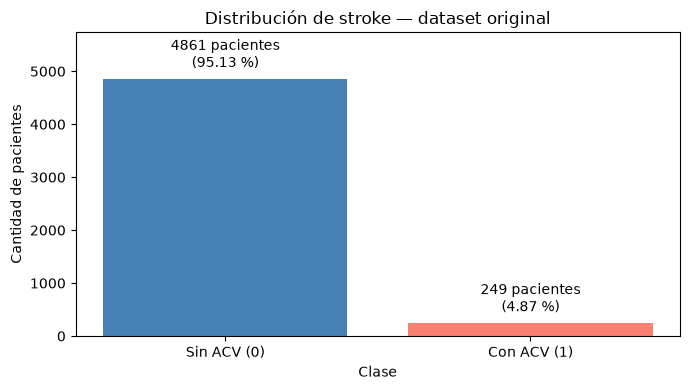

In [50]:
conteos_stroke = df["stroke"].value_counts().reindex([0, 1], fill_value=0)
porcentajes_stroke = 100 * conteos_stroke / conteos_stroke.sum()

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(
    ["Sin ACV (0)", "Con ACV (1)"],
    conteos_stroke.to_numpy(),
    color=["steelblue", "salmon"],
)
for barra, cantidad, porcentaje in zip(barras, conteos_stroke, porcentajes_stroke):
    ax.annotate(
        f"{cantidad} pacientes\n({porcentaje:.2f} %)",
        xy=(barra.get_x() + barra.get_width() / 2, barra.get_height()),
        xytext=(0, 5), textcoords="offset points", ha="center", va="bottom",
    )
ax.set_title("Distribución de stroke — dataset original")
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad de pacientes")
ax.set_ylim(0, conteos_stroke.max() * 1.18)
plt.tight_layout()
plt.show()


Se puede ver un marcado desbalance: 4861 pacientes sin ACV (95.13 %) y 249 con ACV (4.87 %). La clase negativa es aproximadamente 19.5 veces más frecuente. Una predicción siempre negativa alcanzaría una accuracy de 95.13 %, pero no detectaría ningún caso positivo; por ello, se considera necesario evaluar recall, precisión y F2 junto con accuracy.


## 3. Partición e imputación de datos faltantes

### 3.1. Separación de train, validación y test

Se separan los pacientes antes de aprender imputación, codificación y escalado. Las dos divisiones estratificadas producen aproximadamente 60 % para train, 20 % para validación y 20 % para test, y se elimina el Id.


In [51]:
X = df.drop(columns=["stroke", "id"])
y = df["stroke"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=SEED, stratify=y_train_val
)

print(f"Dimensiones de X_train: {X_train.shape} ({len(X_train) / len(df):.0%})")
print(f"Dimensiones de X_val:   {X_val.shape} ({len(X_val) / len(df):.0%})")
print(f"Dimensiones de X_test:  {X_test.shape} ({len(X_test) / len(df):.0%})")

print("\n--- Distribución de 'stroke' (Proporción %) ---")
print(f"Original: \n{y.value_counts(normalize=True).round(4)}")
print(f"Train:    \n{y_train.value_counts(normalize=True).round(4)}")
print(f"Val:      \n{y_val.value_counts(normalize=True).round(4)}")
print(f"Test:     \n{y_test.value_counts(normalize=True).round(4)}")

Dimensiones de X_train: (3066, 10) (60%)
Dimensiones de X_val:   (1022, 10) (20%)
Dimensiones de X_test:  (1022, 10) (20%)

--- Distribución de 'stroke' (Proporción %) ---
Original: 
stroke
0    0.9513
1    0.0487
Name: proportion, dtype: float64
Train:    
stroke
0    0.9514
1    0.0486
Name: proportion, dtype: float64
Val:      
stroke
0    0.9511
1    0.0489
Name: proportion, dtype: float64
Test:     
stroke
0    0.9511
1    0.0489
Name: proportion, dtype: float64


**Justificación de la partición**

Se elimina `id` porque no representa una característica con significado para el problema. La partición 60/20/20 deja 3066 pacientes para ajustar pesos y 1022 para cada evaluación. Es una decisión práctica para disponer de datos de entrenamiento y dos conjuntos separados de evaluación; no se demostró que sea la proporción óptima.

La estratificación conserva aproximadamente el 4.9 % de positivos: 149 en train y 50 tanto en validación como en test. Se toma de train las medianas, la codificación, el escalado y los pesos de la red. Validación permite seleccionar épocas, arquitecturas y umbrales. Test se utiliza con esas decisiones fijadas en el procedimiento actual.


### 3.2. Imputación de BMI

#### 3.2.1. Cálculo de medianas con train

Se preserva train sin imputar y se calculan medianas de BMI observado por edad y género, junto con una mediana global de respaldo. Todos estos valores se calculan exclusivamente con train.


In [52]:
bins = [0, 20, 40, 60, 80, 100]
labels = ["0-20", "20-40", "40-60", "60-80", "80-100"]

# Se preserva train antes de completar los faltantes.
X_train_antes = X_train.copy()
mask_imputados = X_train_antes["bmi"].isna()

# Se obtienen las medianas a partir del BMI observado en train.
X_train_grupos = X_train_antes.copy()
X_train_grupos["age_group"] = pd.cut(
    X_train_grupos["age"], bins=bins, labels=labels, right=False, include_lowest=True
)

bmi_medians = X_train_grupos.groupby(["age_group", "gender"], observed=True)[
    "bmi"
].median()
bmi_global = X_train_antes["bmi"].median()


**Justificación de la imputación**

La mediana reduce la influencia de los BMI extremos frente a la media. Se calcula por intervalos de edad y género para incorporar diferencias descriptivas entre grupos; los intervalos de 20 años son una simplificación explícita. Posteriormenet se muestra un resumen que permite comprobar si esos grupos cuentan con datos y cuánto se apartan de la mediana global.

Las medianas se aprenden únicamente con BMI observado de train, sin usar `stroke`. Se aplican sin recalcularlas a validación y test. La mediana global de train funciona como respaldo cuando un grupo no tiene mediana disponible o una edad queda fuera de los intervalos. Así se evita incorporar información de evaluación al ajuste del imputador.

La estrategia introduce valores centrales repetidos y no recupera la variabilidad ni la incertidumbre de los datos ausentes. Las diferencias por edad respaldan descriptivamente la agrupación, pero no prueban que mejore la predicción frente a una mediana global u otra imputación. Esa comparación requeriría validación específica.


#### 3.2.2. Verificación de las medianas por grupo

A continuación se calcula la cantidad de BMI observados y faltantes, la mediana y el rango intercuartílico por edad y género. Analizamos grupos con menos de 10 observaciones como advertencia exploratoria si es que los hay. También nos aseguramos de disponibilidad de medianas para los faltantes de train y validación.

In [53]:
# BMI original por rango de edad y género
resumen_bmi = X_train_grupos.groupby(
    ["age_group", "gender"], observed=True, dropna=False
)["bmi"].agg(
    pacientes="size",
    observados="count",
    mediana="median",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
)
resumen_bmi["faltantes"] = resumen_bmi["pacientes"] - resumen_bmi["observados"]
resumen_bmi["faltantes_pct"] = 100 * resumen_bmi["faltantes"] / resumen_bmi["pacientes"]
resumen_bmi["iqr"] = resumen_bmi["q3"] - resumen_bmi["q1"]
resumen_bmi["diferencia_mediana_global"] = resumen_bmi["mediana"] - bmi_global
resumen_bmi["pocas_observaciones"] = resumen_bmi["observados"] < 10
resumen_bmi = resumen_bmi[
    [
        "pacientes",
        "observados",
        "faltantes",
        "faltantes_pct",
        "mediana",
        "iqr",
        "diferencia_mediana_global",
        "pocas_observaciones",
    ]
]
display(resumen_bmi.round(2))

print(f"Mediana global observada de train: {bmi_global:.2f}")
print(
    f"Grupos con menos de 10 BMI observados: {int(resumen_bmi['pocas_observaciones'].sum())}"
)
print(f"Grupos sin BMI observado: {int(resumen_bmi['observados'].eq(0).sum())}")

# Se comprueba si los faltantes tienen una mediana de grupo disponible.
for nombre, datos in [("Train", X_train_antes), ("Validación", X_val)]:
    grupos = pd.cut(
        datos["age"], bins=bins, labels=labels, right=False, include_lowest=True
    )
    claves = pd.MultiIndex.from_arrays(
        [grupos, datos["gender"]], names=["age_group", "gender"]
    )
    medianas_disponibles = pd.Series(
        claves.map(bmi_medians).to_numpy(), index=datos.index
    )
    faltantes = datos["bmi"].isna()
    usa_respaldo = faltantes & medianas_disponibles.isna()
    print(
        f"{nombre}: {int(faltantes.sum())} BMI faltantes; "
        f"{int(usa_respaldo.sum())} requieren mediana global."
    )


pacientes  observados  faltantes  faltantes_pct  mediana  \
age_group gender                                                             
0-20      Female        285         278          7           2.46    20.60   
          Male          279         270          9           3.23    20.00   
20-40     Female        492         481         11           2.24    27.60   
          Male          238         225         13           5.46    28.80   
          Other           1           1          0           0.00    22.40   
40-60     Female        555         542         13           2.34    30.10   
          Male          384         364         20           5.21    31.05   
60-80     Female        422         395         27           6.40    29.70   
          Male          304         268         36          11.84    29.50   
80-100    Female         69          66          3           4.35    27.10   
          Male           37          37          0           0.00    28.70   

                    iqr  diferencia_mediana_global  pocas_observaciones  
age_group gender                                                         
0-20      Female   6.35                      -7.50                False  
          Male     5.77                      -8.10                False  
20-40     Female  10.40                      -0.50                False  
          Male     7.80                       0.70                False  
          Other    0.00                      -5.70                 True  
40-60     Female  10.48                       2.00                False  
          Male     7.95                       2.95                False  
60-80     Female   8.50                       1.60                False  
          Male     6.50                       1.40                False  
80-100    Female   8.40                      -1.00                False  
          Male     4.10                       0.60                False

Mediana global observada de train: 28.10
Grupos con menos de 10 BMI observados: 1
Grupos sin BMI observado: 0
Train: 139 BMI faltantes; 0 requieren mediana global.
Validación: 31 BMI faltantes; 0 requieren mediana global.


**Interpretación del resumen**

Mediana global de BMI de 28.10 y diferencias principalmente entre rangos etarios: las medianas se sitúan entre 20.00 y 20.60 en menores de 20 años y entre 30.10 y 31.05 en el grupo de 40–60 años. Las diferencias entre Female y Male dentro de cada rango son menores, lo que respalda descriptivamente la agrupación por edad más que la incorporación de género.

El único grupo con menos de 10 observaciones corresponde a Other (un paciente), sin BMI faltante. Todos los grupos cuentan con BMI observado, por lo que los 139 faltantes de train y los 31 de validación se pueden completar con sus medianas de grupo, sin recurrir al respaldo global. La mayor proporción de faltantes se registra en Male de 60–80 años (11.84 %).

#### 3.2.3. Distribución del BMI observado por grupo



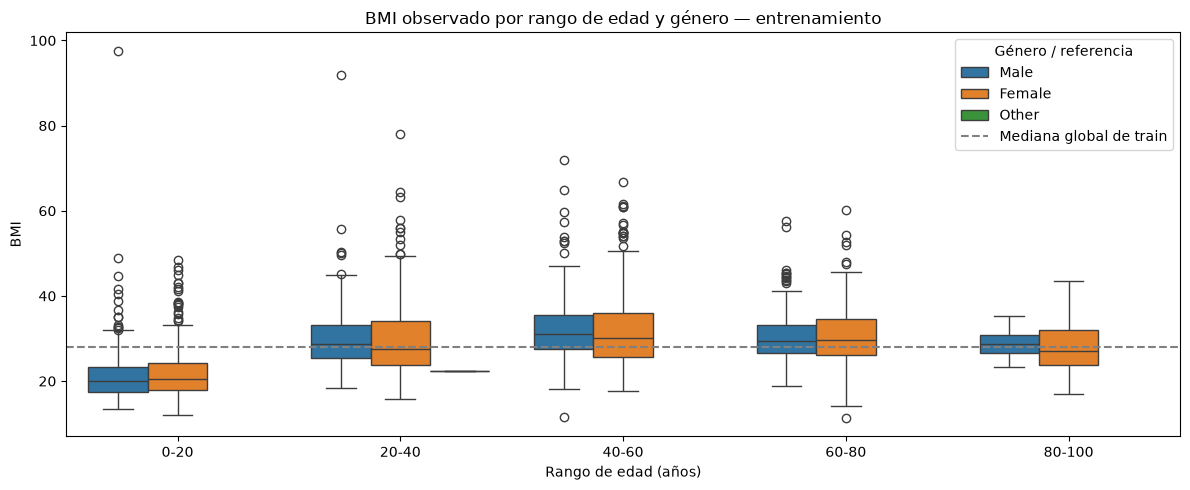

In [54]:
# Se visualizan únicamente los valores observados antes de imputar.
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=X_train_grupos.dropna(subset=["bmi"]),
    x="age_group",
    y="bmi",
    hue="gender",
    ax=ax,
)
ax.axhline(bmi_global, color="gray", linestyle="--", label="Mediana global de train")
ax.set_title("BMI observado por rango de edad y género — entrenamiento")
ax.set_xlabel("Rango de edad (años)")
ax.set_ylabel("BMI")
ax.legend(title="Género / referencia")
plt.tight_layout()
plt.show()


Se observan medianas inferiores a la referencia global (28.10) en menores de 20 años, superiores en el rango de 40–60 años y próximas a ella en los grupos de 20–40 y 80–100 años. En 60–80 años se mantienen ligeramente por encima de la referencia. Las distribuciones de Female y Male presentan un amplio solapamiento dentro de cada rango, con diferencias de mediana menores que las observadas entre edades.

Se registran valores atípicos superiores en varios grupos, lo que respalda el uso de una medida robusta como la mediana. La categoría Other se representa con una única observación y no permite caracterizar una distribución. El gráfico respalda descriptivamente la agrupación por edad, pero no demuestra una mejora predictiva de la imputación por grupos.

#### 3.2.4. Aplicación de la imputación a los tres conjuntos

#### 3.2.4. Aplicación de las medianas

Se completan únicamente los faltantes de los tres conjuntos con las medianas calculadas, conservando sus BMI observados y retirando la columna auxiliar de edad.


In [55]:
# Se aplican las mismas medianas de train a los tres conjuntos.
def imputar_bmi(df, bmi_medians, bmi_global, bins, labels):
    df = df.copy()
    df["age_group"] = pd.cut(
        df["age"], bins=bins, labels=labels, right=False, include_lowest=True
    )
    medianas = df.set_index(["age_group", "gender"]).index.map(bmi_medians)
    df["bmi"] = df["bmi"].fillna(pd.Series(medianas, index=df.index))
    df["bmi"] = df["bmi"].fillna(bmi_global)
    return df.drop(columns="age_group")


X_train = imputar_bmi(X_train_antes, bmi_medians, bmi_global, bins, labels)
X_val = imputar_bmi(X_val, bmi_medians, bmi_global, bins, labels)
X_test = imputar_bmi(X_test, bmi_medians, bmi_global, bins, labels)

print(
    f"BMI faltantes en train: {mask_imputados.sum()} antes -> {X_train['bmi'].isna().sum()} después"
)
print(
    f"BMI faltantes después: val={X_val['bmi'].isna().sum()}, test={X_test['bmi'].isna().sum()}"
)


BMI faltantes en train: 139 antes -> 0 después
BMI faltantes después: val=0, test=0


#### 3.2.5. Comparación antes y después de la imputación

Se comparan los 2927 BMI observados con los 3066 valores resultantes en train, usando los mismos intervalos y límites de los histogramas. El objetivo es revisar el efecto de la imputación usando las medianas en la distribución del conjunto.

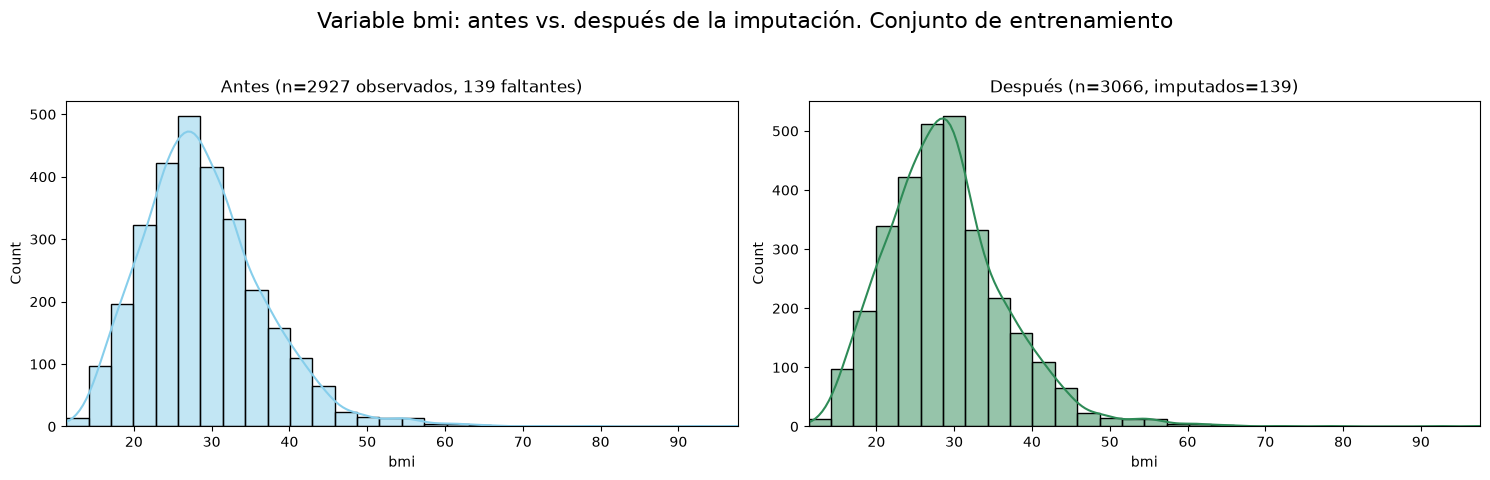

In [56]:
X_train_despues = X_train.copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Variable bmi: antes vs. después de la imputación. Conjunto de entrenamiento", fontsize=16)

# mismos intervalos para comparar ambas distribuciones.
xmin, xmax = X_train_despues["bmi"].min(), X_train_despues["bmi"].max()
bins_hist = np.linspace(xmin, xmax, 31)

sns.histplot(
    data=X_train_antes, x="bmi", bins=bins_hist, kde=True, ax=axes[0], color="skyblue"
)
axes[0].set_title(
    f"Antes (n={X_train_antes['bmi'].notna().sum()} observados, {mask_imputados.sum()} faltantes)"
)

sns.histplot(
    data=X_train_despues,
    x="bmi",
    bins=bins_hist,
    kde=True,
    ax=axes[1],
    color="seagreen",
)
axes[1].set_title(
    f"Después (n={X_train_despues['bmi'].notna().sum()}, imputados={mask_imputados.sum()})"
)

for ax in axes:
    ax.set_xlim(xmin, xmax)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


La imputación incorpora 139 valores, el 4.53 % de train, sin modificar los observados. Se conserva la forma general de la distribución y su cola derecha; las incorporaciones se concentran alrededor de las medianas de grupo. No eliminar extremos ni producir grandes cambios visuales es coherente con el contexto del problema porque son valores posibles.


## 4. EDA

### 4.1. Distribuciones numéricas y frecuencias categóricas

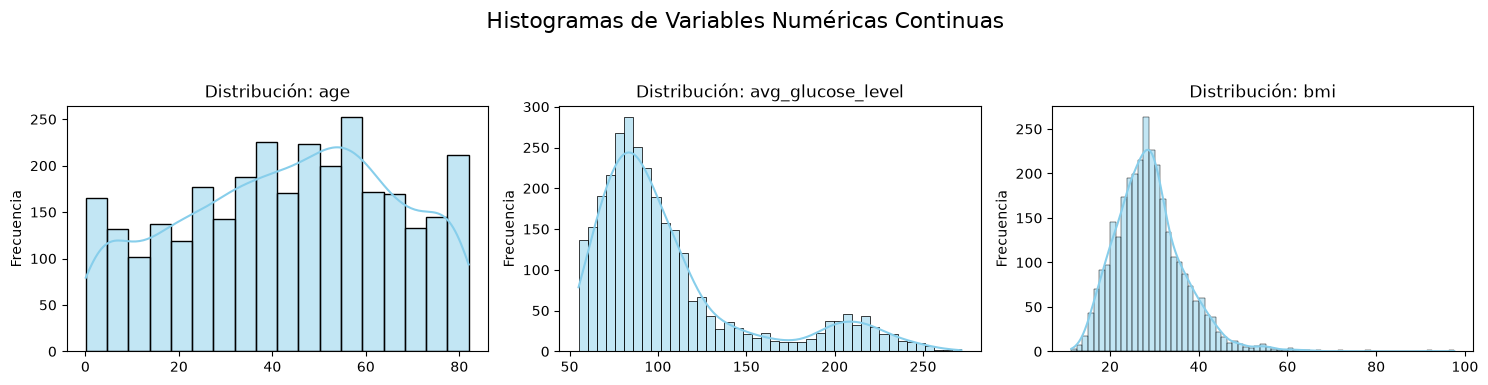

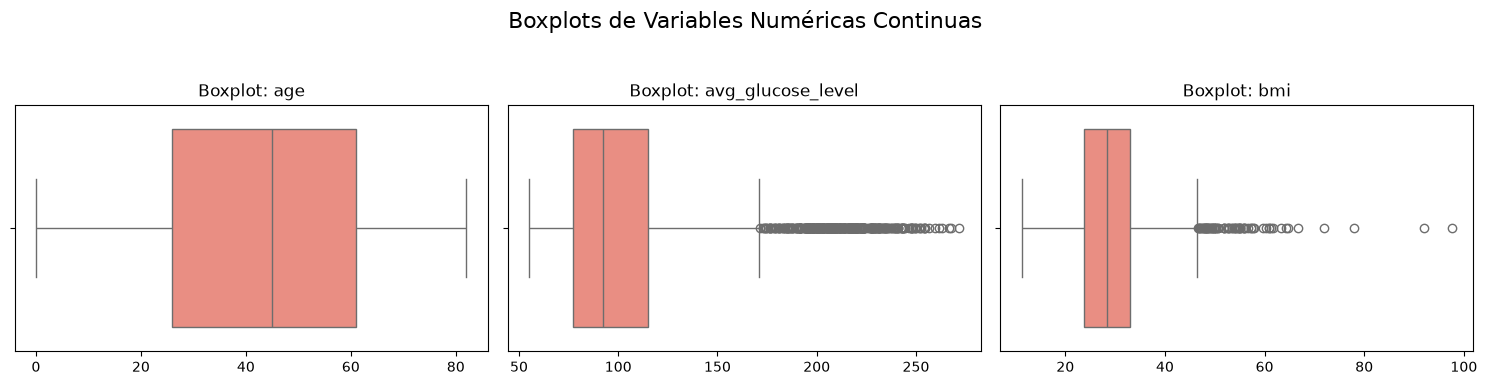

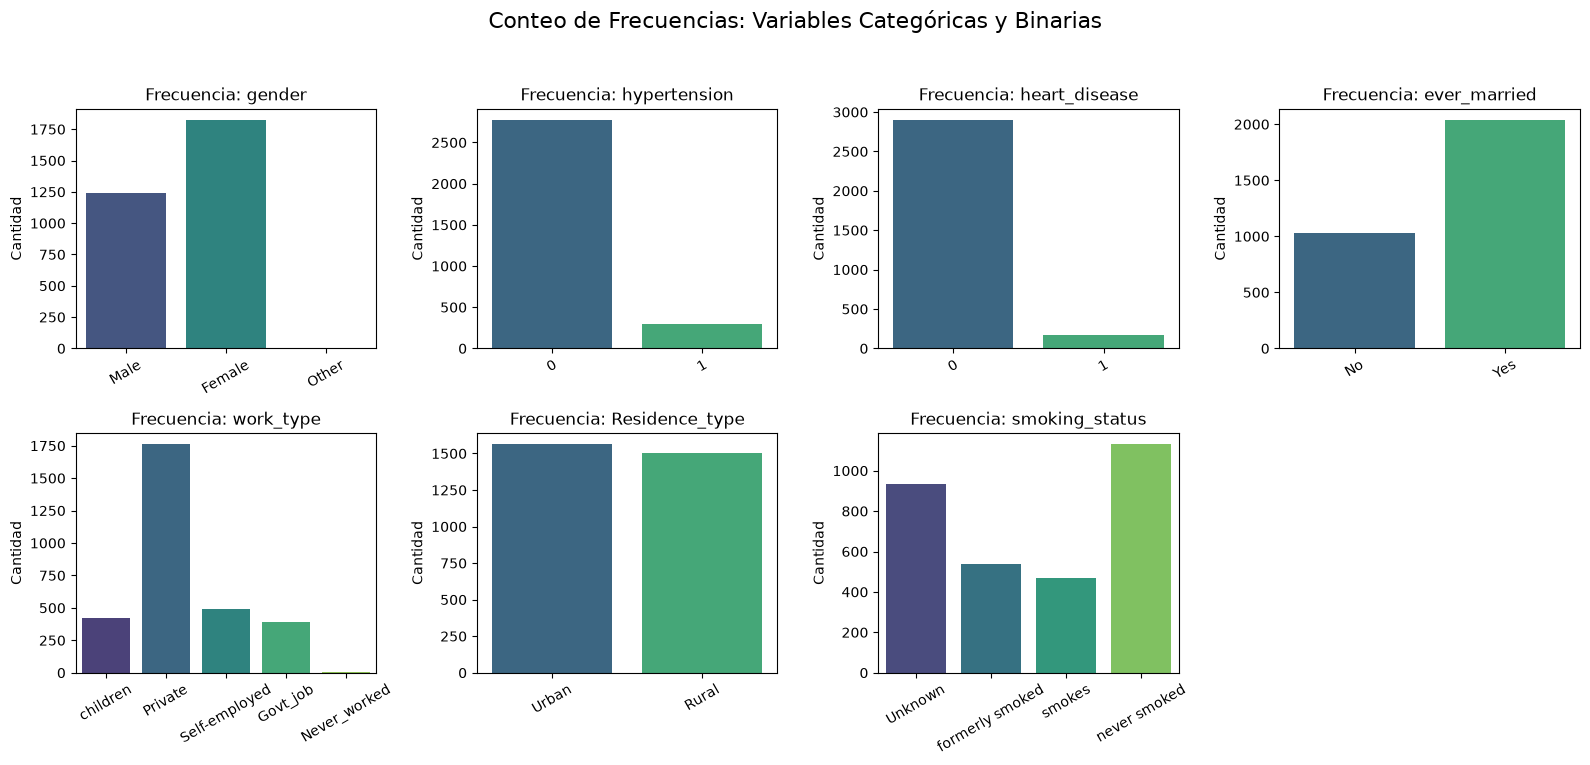

In [57]:
vars_numericas = ["age", "avg_glucose_level", "bmi"]
vars_categoricas = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status",
]

cols = 3
rows = int(np.ceil(len(vars_numericas) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4))
fig.suptitle("Histogramas de Variables Numéricas Continuas", fontsize=16)

axes_flat = np.array(axes).flatten()

for i, col in enumerate(vars_numericas):
    sns.histplot(data=X_train, x=col, kde=True, ax=axes_flat[i], color="skyblue")
    axes_flat[i].set_title(f"Distribución: {col}")
    axes_flat[i].set_xlabel("")
    axes_flat[i].set_ylabel("Frecuencia")

for j in range(len(vars_numericas), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

fig, axes = plt.subplots(rows, cols, figsize=(15, 4))
fig.suptitle("Boxplots de Variables Numéricas Continuas", fontsize=16)

axes_flat = np.array(axes).flatten()

for i, col in enumerate(vars_numericas):
    sns.boxplot(data=X_train, x=col, ax=axes_flat[i], color="salmon")
    axes_flat[i].set_title(f"Boxplot: {col}")
    axes_flat[i].set_xlabel("")

for j in range(len(vars_numericas), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

cols_cat = 4
rows_cat = int(np.ceil(len(vars_categoricas) / cols_cat))

fig, axes = plt.subplots(rows_cat, cols_cat, figsize=(16, 8))
fig.suptitle("Conteo de Frecuencias: Variables Categóricas y Binarias", fontsize=16)

axes_flat_cat = np.array(axes).flatten()

for i, col in enumerate(vars_categoricas):
    ax = axes_flat_cat[i]
    sns.countplot(data=X_train, x=col, ax=ax, palette="viridis", hue=col, legend=False)
    ax.set_title(f"Frecuencia: {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis="x", rotation=30)

for j in range(len(vars_categoricas), len(axes_flat_cat)):
    fig.delaxes(axes_flat_cat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Se procede a explorar únicamente train para describir las vraiables continuas y las frecuencias de categorías. Para la exploración se utilizan histogramas muestran la forma de las distribuciones y los boxplots su dispersión y extremos. También se efectuan conteos para identificar si hay grupos escasos.

**Interpretación**

La edad cubre desde 0.08 hasta 82 años, con mediana 45, y no presenta la cola derecha pronunciada de las otras continuas. La glucosa tiene mediana 92.11 y media 106.75, con valores de hasta 271.74; BMI tiene mediana 28.35, media 29.00 y máximo 97.60. Los histogramas y boxplots muestran asimetría positiva y valores altos alejados de la zona central en glucosa y BMI.

**Se conservan los extremos**. Se decide no eliminarlos porque podría suprimir información útil y cambiar la población estudiada y la distribución.

Las categorías también son desiguales: predominan `Female`, `Private` y los pacientes sin hipertensión ni enfermedad cardíaca. `Other` contiene un solo paciente y `Never_worked`, siete. Sus frecuencias y proporciones no sostienen conclusiones generales. `Unknown` en tabaquismo reúne 932 pacientes, por lo que se decidió conservarlo tal cual está porque mantiene una parte relevante de los datos.


### 4.2. Glucosa y BMI según la presencia de ACV


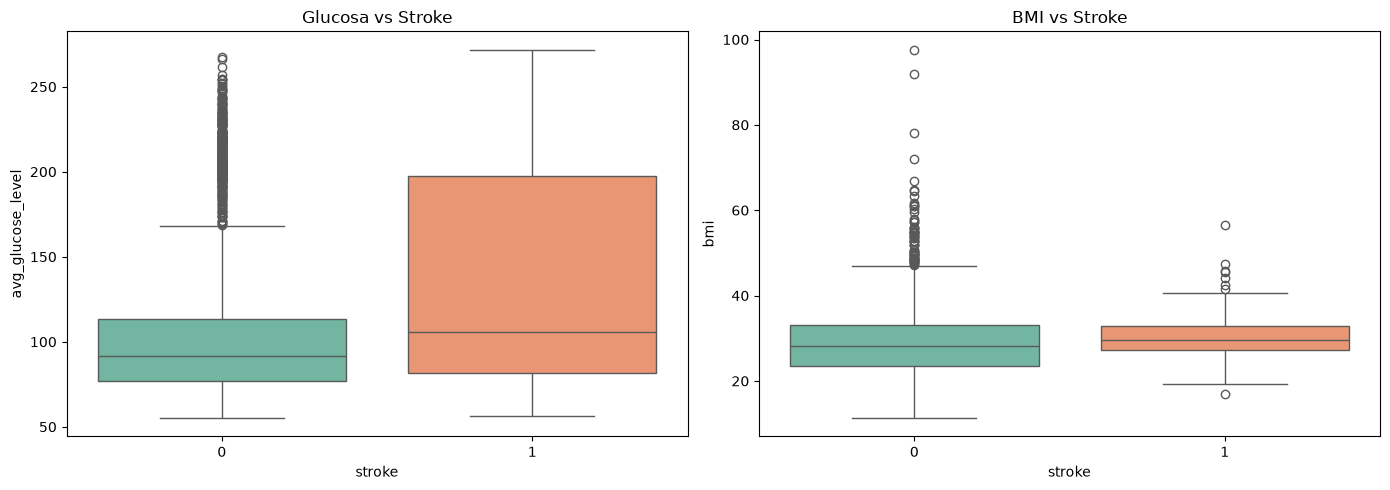

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=X_train.assign(stroke=y_train),
    x="stroke",
    hue="stroke",
    legend=False,
    y="avg_glucose_level",
    ax=axes[0],
    palette="Set2",
)
axes[0].set_title("Glucosa vs Stroke")

sns.boxplot(
    data=X_train.assign(stroke=y_train),
    x="stroke",
    hue="stroke",
    legend=False,
    y="bmi",
    ax=axes[1],
    palette="Set2",
)
axes[1].set_title("BMI vs Stroke")

plt.tight_layout()
plt.show()


Se comparan las distribuciones de glucosa y BMI entre positivos y negativos de train. Se busca describir diferencias y solapamientos, sin inferir causalidad ni fijar reglas de diagnóstico.

En train, la mediana de glucosa es 105.92 entre los positivos y 91.65 entre los negativos. Para BMI, las medianas son 29.70 y 28.20, respectivamente. Existe una diferencia de ubicación, especialmente en glucosa, pero también un amplio solapamiento. Ninguna de las dos variables ofrece por sí sola una separación clara entre clases.

Son asociaciones descriptivas de este conjunto. No prueban causalidad ni permiten establecer un umbral diagnóstico. El boxplot de BMI también incorpora los valores imputados, por lo que su distribución refleja esa decisión de preprocesamiento.


### 4.3. Correlaciones entre variables numéricas y binarias


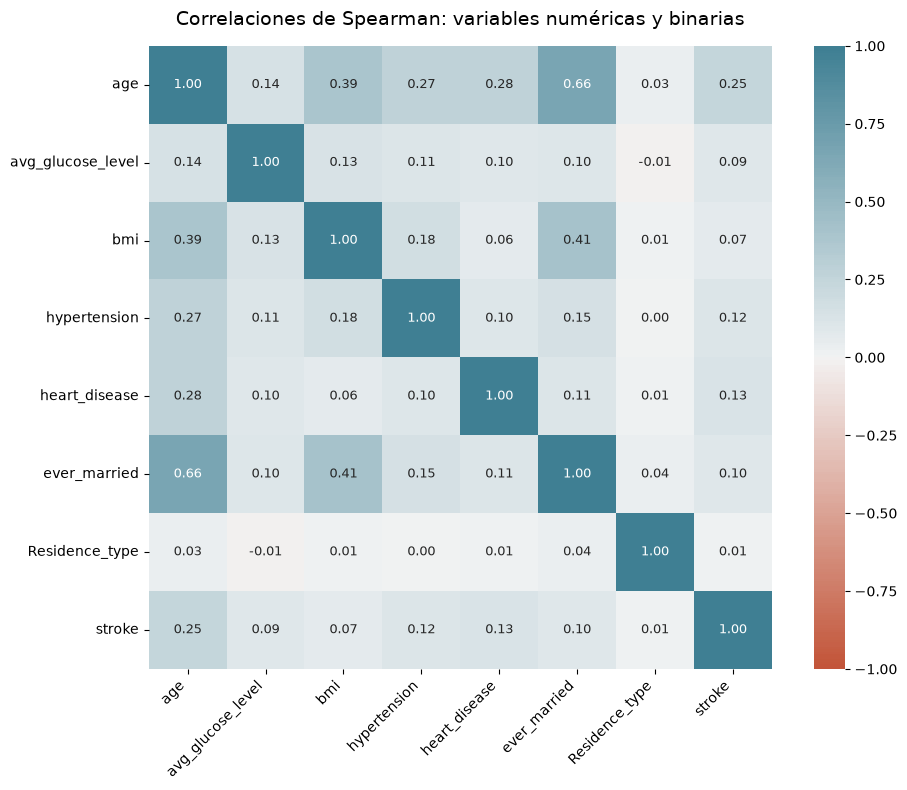

In [59]:
# Se utiliza exclusivamente el conjunto de entrenamiento original.
df_train = pd.concat([X_train, y_train], axis=1)
cols_corr = [
    "age",
    "avg_glucose_level",
    "bmi",
    "hypertension",
    "heart_disease",
    "ever_married",
    "Residence_type",
    "stroke",
]
df_corr = df_train[cols_corr].copy()

# Se asigna explícitamente el significado de las categorías binarias.
df_corr["ever_married"] = df_corr["ever_married"].map({"No": 0, "Yes": 1})
df_corr["Residence_type"] = df_corr["Residence_type"].map({"Rural": 0, "Urban": 1})
if df_corr.isna().any().any():
    raise ValueError("Se detectaron faltantes o categorías binarias no reconocidas.")

corr = df_corr.corr(method="spearman")
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment="right")
plt.title(
    "Correlaciones de Spearman: variables numéricas y binarias", fontsize=14, pad=15
)
plt.tight_layout()
plt.show()



Se calcula Spearman sobre train para examinar relaciones de rangos entre continuas y binarias. Las binarias nominales se mapean explícitamente. Las categorías sin orden con más de dos valores se estudian en el bloque siguiente.

Se observa que en el gráfico de correlación la edad presenta la mayor correlación de Spearman con `stroke` entre las variables examinadas (0.25). Le siguen enfermedad cardíaca (0.13), hipertensión (0.12) y matrimonio previo (0.10); glucosa (0.09), BMI (0.07) y residencia urbana (0.01) muestran asociaciones marginales menores.

Edad y matrimonio previo también están asociados (0.66), lo que ilustra que una relación con `stroke` puede compartir información con otras variables. Una correlación baja no justifica descartar automáticamente una variable que podría aportar interacciones o relaciones no monótonas. Las categorías nominales con más de dos valores se analizan por separado para no imponerles un orden arbitrario.


### 4.4. Asociación de variables nominales con ACV

A continuación se calcula la cantidad de pacientes, el número de positivos y la proporción de stroke=1 por categoría, exclusivamente en train. Además, se presentan los tamaños de grupo y la prevalencia total como referencias para evitar confundir frecuencia absoluta con proporción de positivos.

pacientes  positivos  stroke_pct
variable       categoria                                        
gender         Female                1823         85        4.66
               Male                  1242         64        5.15
               Other                    1          0        0.00
work_type      Govt_job               388         21        5.41
               Never_worked             7          0        0.00
               Private               1760         89        5.06
               Self-employed          490         38        7.76
               children               421          1        0.24
smoking_status Unknown                932         29        3.11
               formerly smoked        537         44        8.19
               never smoked          1130         49        4.34
               smokes                 467         27        5.78

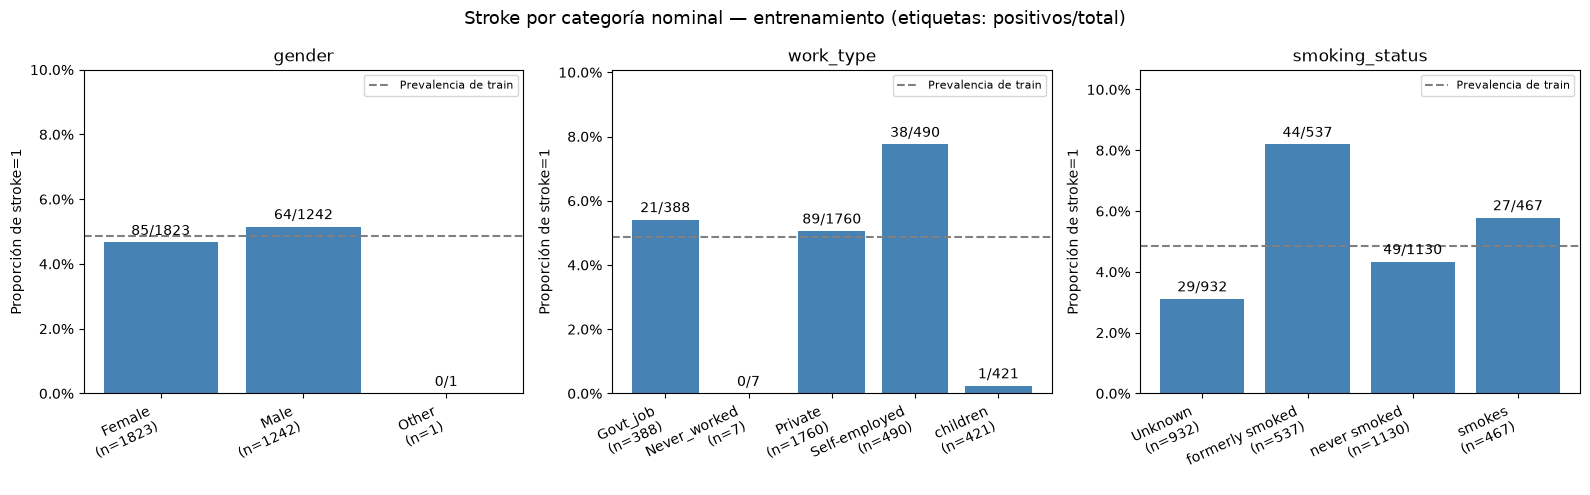

In [60]:
from matplotlib.ticker import PercentFormatter

# Se conservan las categorías nominales sin imponer un orden numérico.
vars_nominales = ["gender", "work_type", "smoking_status"]
resumen_nominales = {}
for col in vars_nominales:
    resumen = df_train.groupby(col, observed=True, dropna=False)["stroke"].agg(
        pacientes="size", positivos="sum", proporcion="mean"
    )
    resumen["positivos"] = resumen["positivos"].astype(int)
    resumen["stroke_pct"] = resumen["proporcion"] * 100
    resumen_nominales[col] = resumen

tabla_nominales = pd.concat(resumen_nominales, names=["variable", "categoria"])
display(tabla_nominales[["pacientes", "positivos", "stroke_pct"]].round(2))

# Se compara la proporción por categoría con la prevalencia global de train.
prevalencia_train = y_train.mean()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, vars_nominales):
    resumen = resumen_nominales[col]
    bars = ax.bar(np.arange(len(resumen)), resumen["proporcion"], color="steelblue")
    ax.set_xticks(np.arange(len(resumen)))
    ax.set_xticklabels(
        [f"{cat}\n(n={int(row['pacientes'])})" for cat, row in resumen.iterrows()],
        rotation=25,
        ha="right",
    )
    ax.bar_label(
        bars,
        labels=[
            f"{int(row['positivos'])}/{int(row['pacientes'])}"
            for _, row in resumen.iterrows()
        ],
        padding=3,
    )
    ax.axhline(
        prevalencia_train, color="gray", linestyle="--", label="Prevalencia de train"
    )
    ax.set_title(col)
    ax.set_ylabel("Proporción de stroke=1")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.set_ylim(0, max(0.1, resumen["proporcion"].max() * 1.3))
    ax.legend(fontsize=8)
fig.suptitle(
    "Stroke por categoría nominal — entrenamiento (etiquetas: positivos/total)",
    fontsize=13,
)
plt.tight_layout()
plt.show()


Las proporciones de positivos en `Female` (4.66 %) y `Male` (5.15 %) son cercanas a la prevalencia de train (4.86 %). El 0 % de `Other` corresponde a un único paciente y no demuestra ausencia de asociación. Lo mismo sucede con los siete pacientes de `Never_worked`, sin positivos observados.

`Self-employed` registra 38/490 positivos (7.76 %), mientras que `children` presenta 1/421 (0.24 %). En tabaquismo, `formerly smoked` alcanza 44/537 (8.19 %), `smokes` 27/467 (5.78 %), `never smoked` 49/1130 (4.34 %) y `Unknown` 29/932 (3.11 %). Las proporciones permiten comparar grupos de distinto tamaño y los conteos permiten juzgar cuánto sustento tiene cada proporción.

No se concluye que una ocupación o categoría de tabaquismo cause o proteja frente a ACV. Las diferencias pueden estar relacionadas con edad y otras características.


## 5. Codificación y escalado

Se construye un transformador común **StandardScaler** para las tres variables continuas y One-Hot para categóricas y binarias. Se aprende la representación en train y se comprueba que validación y test compartan el mismo número de columnas.


In [61]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), vars_numericas),
        (
            "categoricas",
            OneHotEncoder(drop="first", sparse_output=False),
            vars_categoricas,
        ),
    ]
)


X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print(f"Forma de X_train procesado: {X_train_prep.shape}")
print(f"Forma de X_val procesado:   {X_val_prep.shape}")
print(f"Forma de X_test procesado:  {X_test_prep.shape}")

Forma de X_train procesado: (3066, 16)
Forma de X_val procesado:   (1022, 16)
Forma de X_test procesado:  (1022, 16)


**Justificación de la codificación y el escalado**

One-Hot representa cada categoría mediante indicadores y evita asignar distancias u órdenes artificiales a variables como ocupación o tabaquismo. `drop="first"` deja una categoría de referencia por variable, sus indicadores son todos cero y las restantes categorías tienen su indicador correspondiente. Así se reducen columnas redundantes sin eliminar pacientes. Las binarias quedan representadas por una sola columna.

StandardScaler centra edad, glucosa y BMI usando la media de train y divide por su desviación estándar. Homogeneizar sus escalas ayuda a la optimización de la red. Como usa media y desviación sigue siendo sensible a los extremos conservados. Los indicadores categóricos no se escalan.

El transformador se ajusta solo con train y se aplica sin reajustarlo a validación y test.


## 6. Tratamiento del desbalance y entrenamiento de los MLP

Se comparan dos formas de aumentar la influencia de los positivos durante el entrenamiento: 
 - generar registros sintéticos con BorderlineSMOTE
 - ponderar su contribución a la pérdida con `pos_weight`. 
 
Validación y test conservan las clases originales para evaluar el compromiso entre detecciones y falsos positivos sobre el desbalance del dataset.


### 6.1. Sobremuestreo de train con BorderlineSMOTE

La primera prueba utiliza BorderlineSMOTE para sobremuestrear la clase minoritaria **únicamente en train**.


In [62]:
border_smote = BorderlineSMOTE(random_state=SEED)
X_train_smote, y_train_smote = border_smote.fit_resample(X_train_prep, y_train)

num_features = X_train_smote.shape[1]

print("--- Distribución de 'stroke' antes de BorderlineSMOTE ---")
print(y_train.value_counts())

print("\n--- Distribución de 'stroke' después de BorderlineSMOTE ---")
print(pd.Series(y_train_smote).value_counts())

--- Distribución de 'stroke' antes de BorderlineSMOTE ---
stroke
0    2917
1     149
Name: count, dtype: int64

--- Distribución de 'stroke' después de BorderlineSMOTE ---
stroke
0    2917
1    2917
Name: count, dtype: int64


**Resultado y alcance del sobremuestreo**

Train pasa de 2917 negativos y 149 positivos a 2917 registros por clase: se agregan 2768 positivos sintéticos. BorderlineSMOTE concentra la generación cerca de la frontera estimada entre clases. Esos registros no son pacientes nuevos independientes.

### 6.2. Entrenamiento del MLP con BorderlineSMOTE

Se utiliza la misma arquitectura que con se aplicará en `pos_weight` para fines de comparación. 16 entradas, una capa oculta de 64 neuronas, ReLU, dropout 0.3 y una salida. Se mantienen Adam, learning rate 0.001, weight_decay 0.0001, minibatches de 64, semilla 42, máximo de 500 épocas, paciencia 30 y min_delta 0.0001.

BorderlineSMOTE utiliza train sobremuestreado y pérdida sin ponderar. `pos_weight` utiliza train original y pérdida ponderada. Al finalizar cada época, ambos evalúan train original y validación.


In [63]:
import copy
import random

# Semillas antes de inicializar pesos y barajar los minibatches.
fijar_semilla()


class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(out)


# Train sobremuestreado: es el único conjunto que actualiza pesos.
X_train_tensor = torch.tensor(np.asarray(X_train_smote), dtype=torch.float32)
y_train_tensor = torch.tensor(np.asarray(y_train_smote), dtype=torch.float32).view(
    -1, 1
)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Validación: mismos pasos de preprocesamiento, sin sobremuestreo.
X_val_tensor = torch.tensor(np.asarray(X_val_prep), dtype=torch.float32)
y_val_tensor = torch.tensor(np.asarray(y_val), dtype=torch.float32).view(-1, 1)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Train original para diagnosticar curvas con el desbalance real.
X_train_original_tensor = torch.tensor(np.asarray(X_train_prep), dtype=torch.float32)
y_train_original_tensor = torch.tensor(np.asarray(y_train), dtype=torch.float32).view(
    -1, 1
)
train_original_dataset = TensorDataset(X_train_original_tensor, y_train_original_tensor)
train_eval_loader = DataLoader(train_original_dataset, batch_size=64, shuffle=False)

model = MLP(input_dim=num_features, hidden_dim=64, dropout_rate=0.3)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


def evaluar_modelo(loader):
    # eval() apaga dropout; no_grad() evita calcular gradientes.
    model.eval()
    loss_sum = 0.0
    total = 0
    true_positives = 0
    false_negatives = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            logits = model(batch_x)
            loss_sum += criterion(logits, batch_y).item() * batch_x.size(0)
            total += batch_x.size(0)
            # Umbral fijo 0.5: equivale a logits >= 0. No se busca un umbral aquí.
            predictions = logits >= 0
            positives = batch_y == 1
            true_positives += (predictions & positives).sum().item()
            false_negatives += ((~predictions) & positives).sum().item()
    if total == 0:
        raise ValueError("No se puede evaluar un conjunto vacío.")
    positive_count = true_positives + false_negatives
    recall = true_positives / positive_count if positive_count else float("nan")
    return loss_sum / total, recall


epochs = 500
patience = 30
min_delta = 1e-4
best_val_loss = float("inf")
best_model_weights = None
best_epoch = None
epochs_without_improvement = 0
history = []

print("Train actualiza pesos; validación selecciona la época; test no participa.")
for epoch in range(1, epochs + 1):
    model.train()  # Reactivar dropout tras las evaluaciones de la época anterior.
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)

    # Evaluación de train original y val con los mismos pesos y dropout apagado.
    train_loss, train_recall = evaluar_modelo(train_eval_loader)
    val_loss, val_recall = evaluar_modelo(val_loader)
    history.append(
        {
            "epoch": epoch,
            "optimization_loss": running_loss / len(train_dataset),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_recall": train_recall,
            "val_recall": val_recall,
        }
    )
    improved = val_loss < best_val_loss - min_delta
    if improved:
        best_val_loss = val_loss
        best_epoch = epoch
        # Copia independiente en memoria: no sobrescribe archivos de checkpoints.
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Todas las métricas siguen en history; solo se reduce la salida de consola.
    if epoch % 10 == 0 or epochs_without_improvement == 1:
        status = (
            "Mejora de validación"
            if improved
            else f"Sin mejora suficiente | Paciencia: {epochs_without_improvement}/{patience}"
        )
        print(
            f"Época {epoch:02d}/{epochs} | Loss train: {train_loss:.4f} "
            f"| Loss val: {val_loss:.4f} | Recall train: {train_recall:.3f} "
            f"| Recall val: {val_recall:.3f} | {status}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping: {patience} épocas sin mejora suficiente.")
        break

if best_model_weights is None:
    raise RuntimeError("No se obtuvo un checkpoint válido; revisar datos y pérdidas.")
model.load_state_dict(best_model_weights)
model.eval()
print(f"Mejores pesos restaurados: época {best_epoch}, val loss = {best_val_loss:.4f}")

# Conservar este experimento separado de la alternativa con pos_weight.
model_smote = copy.deepcopy(model)


Train actualiza pesos; validación selecciona la época; test no participa.
Época 06/500 | Loss train: 0.4000 | Loss val: 0.3932 | Recall train: 0.799 | Recall val: 0.680 | Sin mejora suficiente | Paciencia: 1/30
Época 08/500 | Loss train: 0.3924 | Loss val: 0.3871 | Recall train: 0.799 | Recall val: 0.680 | Sin mejora suficiente | Paciencia: 1/30
Época 10/500 | Loss train: 0.3707 | Loss val: 0.3680 | Recall train: 0.799 | Recall val: 0.640 | Mejora de validación
Época 11/500 | Loss train: 0.3728 | Loss val: 0.3704 | Recall train: 0.805 | Recall val: 0.660 | Sin mejora suficiente | Paciencia: 1/30
Época 14/500 | Loss train: 0.3697 | Loss val: 0.3701 | Recall train: 0.805 | Recall val: 0.660 | Sin mejora suficiente | Paciencia: 1/30
Época 17/500 | Loss train: 0.3441 | Loss val: 0.3494 | Recall train: 0.785 | Recall val: 0.620 | Sin mejora suficiente | Paciencia: 1/30
Época 20/500 | Loss train: 0.3412 | Loss val: 0.3505 | Recall train: 0.785 | Recall val: 0.600 | Sin mejora suficiente | Pa

**Justificación del MLP y del entrenamiento**

La capa oculta combina las 16 entradas y ReLU introduce no linealidad, permitiendo aprender relaciones que una transformación lineal sola no representa. Es una activación sencilla, sin saturación en su rama positiva, aunque puede dejar unidades inactivas en la rama negativa. La red 16–64–1 tiene 1153 parámetros: una capacidad inicial que luego se contrasta con alternativas.

La salida es un único logit, sin sigmoid dentro del modelo. `BCEWithLogitsLoss` combina sigmoid y entropía cruzada binaria con una formulación numéricamente estable. Para obtener scores entre 0 y 1 se aplica sigmoid durante la evaluación.

Adam adapta la actualización por parámetro a partir de los gradientes. `lr=0.001` se adopta como punto de partida y se mantiene en las comparaciones. Los minibatches de 64 permiten actualizaciones frecuentes sin procesar todo train en cada paso.

Dropout 0.3 anula aleatoriamente activaciones ocultas durante el entrenamiento para reducir dependencias excesivas entre unidades. `weight_decay=0.0001` penaliza magnitudes grandes de pesos en esta configuración de Adam. Ambos buscan limitar sobreajuste, sin garantizar que desaparezca. En evaluación se desactiva dropout mediante `eval()` y se evita construir gradientes con `no_grad()`.

Early stopping conserva una copia de los pesos cuando la pérdida de validación mejora más de 0.0001 y detiene el ajuste tras 30 épocas consecutivas sin mejora suficiente. El límite de 500 épocas es un máximo. Seleccionar pesos por pérdida usa un criterio continuo y seleccionar después el umbral por F2 adapta la decisión binaria


### 6.3. Curvas de entrenamiento con BorderlineSMOTE


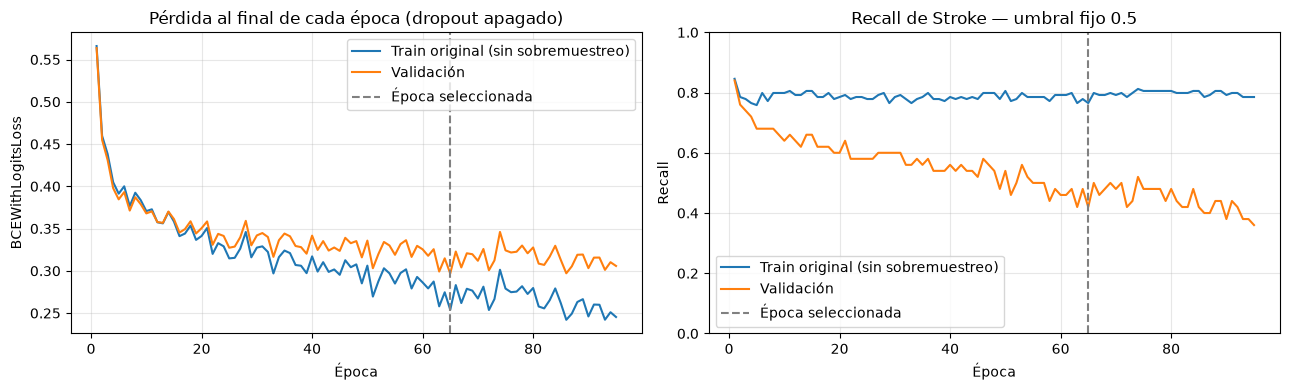

In [64]:
epochs_run = [row["epoch"] for row in history]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for prefix, label in [
    ("train", "Train original (sin sobremuestreo)"),
    ("val", "Validación"),
]:
    axes[0].plot(epochs_run, [row[f"{prefix}_loss"] for row in history], label=label)
    axes[1].plot(epochs_run, [row[f"{prefix}_recall"] for row in history], label=label)

axes[0].set_title("Pérdida al final de cada época (dropout apagado)")
axes[0].set_ylabel("BCEWithLogitsLoss")
axes[1].set_title("Recall de Stroke — umbral fijo 0.5")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1)
for ax in axes:
    ax.axvline(best_epoch, color="gray", linestyle="--", label="Época seleccionada")
    ax.set_xlabel("Época")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


Se representan pérdida y recall por época sobre train y validación, con dropout desactivado. La línea vertical marca el checkpoint restaurado. Recall mantiene umbral 0.5 durante todo el historial.

La pérdida de train disminuye durante el ajuste, mientras la de validación presenta oscilaciones y deja de mejorar de manera sostenida. Train también presenta oscilaciones. Se restauran los pesos de la época 65, con pérdida de validación 0.2969; con paciencia 30, el entrenamiento se detiene en la época 95. Las últimas épocas sirven para verificar la falta de mejora y no definen los pesos finales.

El recall de validación con umbral 0.5 cae aproximadamente de 0.68 en etapas iniciales a valores cercanos a 0.4 al final. Esto puede coexistir con una reducción de pérdida: la BCE evalúa los scores de todos los pacientes, mientras recall solo cuenta positivos que cruzan un umbral. Una mejora agregada puede acompañarse de más positivos por debajo de 0.5.

Las curvas evalúan train y validación con los mismos pesos y dropout apagado para compararlas.Se puede observar la separación creciente entre sus pérdidas que sugiere sobreajuste.


### 6.4. Entrenamiento del MLP con `pos_weight`

Como segundo método se decidió probar con pos_weight, dándole más peso a la clase minoritaria.

Se utiliza inicialmente una capa oculta de 64 neuronas con ReLU y dropout 0.3. Esta configuración se toma como punto de partida y se contrasta con alternativas en el bloque siguiente.


In [65]:
import copy
import random

fijar_semilla()

X_tr_np = (
    X_train_prep.values if hasattr(X_train_prep, "values") else np.array(X_train_prep)
)
y_tr_np = y_train.values if hasattr(y_train, "values") else np.array(y_train)


X_train_t = torch.tensor(X_tr_np, dtype=torch.float32)
y_train_t = torch.tensor(y_tr_np, dtype=torch.float32).view(-1, 1)


batch_size = 64
dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


class CleanMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout_rate=0.3):
        super(CleanMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)


num_negatives = (y_tr_np == 0).sum()
num_positives = (y_tr_np == 1).sum()
if num_positives == 0 or num_negatives == 0:
    raise ValueError("Se requieren ambas clases en train.")
weight_val = num_negatives / num_positives

pos_weight = torch.tensor([weight_val], dtype=torch.float32)
print(f"Peso asignado a la clase 'Stroke': {weight_val:.2f}")

num_features = X_tr_np.shape[1]
model_pos_weight = CleanMLP(input_dim=num_features, hidden_dim=64, dropout_rate=0.3)

criterion_pos_weight = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_pos_weight = optim.Adam(
    model_pos_weight.parameters(), lr=0.001, weight_decay=1e-4
)


# Train original: no se generan ni se usan ejemplos sintéticos.
train_dataset = dataset
train_eval_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
X_val_tensor = torch.tensor(np.asarray(X_val_prep), dtype=torch.float32)
y_val_tensor = torch.tensor(np.asarray(y_val), dtype=torch.float32).view(-1, 1)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


def evaluar_pos_weight(loader):
    # eval() apaga dropout; no_grad() evita calcular gradientes.
    model_pos_weight.eval()
    loss_sum = 0.0
    total = 0
    true_positives = 0
    false_negatives = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            logits = model_pos_weight(batch_x)
            loss_sum += criterion_pos_weight(logits, batch_y).item() * batch_x.size(0)
            total += batch_x.size(0)
            # Umbral fijo 0.5: equivale a logits >= 0. No se busca un umbral aquí.
            predictions = logits >= 0
            positives = batch_y == 1
            true_positives += (predictions & positives).sum().item()
            false_negatives += ((~predictions) & positives).sum().item()
    if total == 0:
        raise ValueError("No se puede evaluar un conjunto vacío.")
    positive_count = true_positives + false_negatives
    recall = true_positives / positive_count if positive_count else float("nan")
    return loss_sum / total, recall


epochs_pos_weight = 500
patience_pos_weight = 30
min_delta_pos_weight = 1e-4
best_val_loss_pos_weight = float("inf")
best_weights_pos_weight = None
best_epoch_pos_weight = None
bad_epochs_pos_weight = 0
history_pos_weight = []

print(
    "Train original ajusta pesos con pos_weight; validación selecciona la época; test no participa."
)
for epoch in range(1, epochs_pos_weight + 1):
    model_pos_weight.train()  # Reactivar dropout tras las evaluaciones de la época anterior.
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer_pos_weight.zero_grad()
        logits = model_pos_weight(batch_x)
        loss = criterion_pos_weight(logits, batch_y)
        loss.backward()
        optimizer_pos_weight.step()
        running_loss += loss.item() * batch_x.size(0)

    # Evaluación de train original y val con los mismos pesos y dropout apagado.
    train_loss, train_recall = evaluar_pos_weight(train_eval_loader)
    val_loss, val_recall = evaluar_pos_weight(val_loader)
    history_pos_weight.append(
        {
            "epoch": epoch,
            "optimization_loss": running_loss / len(train_dataset),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_recall": train_recall,
            "val_recall": val_recall,
        }
    )
    improved = val_loss < best_val_loss_pos_weight - min_delta_pos_weight
    if improved:
        best_val_loss_pos_weight = val_loss
        best_epoch_pos_weight = epoch
        # Copia independiente en memoria: no sobrescribe archivos de checkpoints.
        best_weights_pos_weight = copy.deepcopy(model_pos_weight.state_dict())
        bad_epochs_pos_weight = 0
    else:
        bad_epochs_pos_weight += 1

    # Todas las métricas siguen en history_pos_weight; solo se reduce la salida de consola.
    if epoch % 10 == 0 or bad_epochs_pos_weight == 1:
        status = (
            "Mejora de validación"
            if improved
            else f"Sin mejora suficiente | Paciencia: {bad_epochs_pos_weight}/{patience_pos_weight}"
        )
        print(
            f"Época {epoch:02d}/{epochs_pos_weight} | Loss train: {train_loss:.4f} "
            f"| Loss val: {val_loss:.4f} | Recall train: {train_recall:.3f} "
            f"| Recall val: {val_recall:.3f} | {status}"
        )

    if bad_epochs_pos_weight >= patience_pos_weight:
        print(f"Early stopping: {patience_pos_weight} épocas sin mejora suficiente.")
        break

if best_weights_pos_weight is None:
    raise RuntimeError("No se obtuvo un checkpoint válido; revisar datos y pérdidas.")
model_pos_weight.load_state_dict(best_weights_pos_weight)
model_pos_weight.eval()
print(
    f"Mejores pesos restaurados: época {best_epoch_pos_weight}, val loss = {best_val_loss_pos_weight:.4f}"
)


Peso asignado a la clase 'Stroke': 19.58
Train original ajusta pesos con pos_weight; validación selecciona la época; test no participa.
Época 10/500 | Loss train: 0.8788 | Loss val: 0.9009 | Recall train: 0.852 | Recall val: 0.880 | Mejora de validación
Época 12/500 | Loss train: 0.8717 | Loss val: 0.9017 | Recall train: 0.846 | Recall val: 0.840 | Sin mejora suficiente | Paciencia: 1/30
Época 14/500 | Loss train: 0.8673 | Loss val: 0.8997 | Recall train: 0.852 | Recall val: 0.860 | Sin mejora suficiente | Paciencia: 1/30
Época 17/500 | Loss train: 0.8614 | Loss val: 0.8981 | Recall train: 0.859 | Recall val: 0.860 | Sin mejora suficiente | Paciencia: 1/30
Época 20/500 | Loss train: 0.8558 | Loss val: 0.8959 | Recall train: 0.859 | Recall val: 0.860 | Sin mejora suficiente | Paciencia: 4/30
Época 30/500 | Loss train: 0.8392 | Loss val: 0.9094 | Recall train: 0.859 | Recall val: 0.820 | Sin mejora suficiente | Paciencia: 14/30
Época 40/500 | Loss train: 0.8235 | Loss val: 0.9130 | Recal

`pos_weight` se calcula exclusivamente con train: $w_+=2917/149=19.58$. En la BCE, multiplica el término correspondiente a etiquetas positivas, aumentando su influencia relativa sobre los gradientes. Con esta razón, las cantidades de ambas clases tendrían una contribución total comparable si sus pérdidas individuales fueran iguales.

La ponderación permite usar los registros originales sin interpolar categorías. Se podría decir que es una solución más simple, y siguiendo el principio de parsimonia la ubica en una mejor posición.


### 6.5. Curvas de entrenamiento con `pos_weight`

Se inspeccionan pérdida ponderada y recall de train original y validación para reconocer cuándo el ajuste adicional deja de generalizar. La línea indica el checkpoint elegido por pérdida; recall usa umbral fijo 0.5.


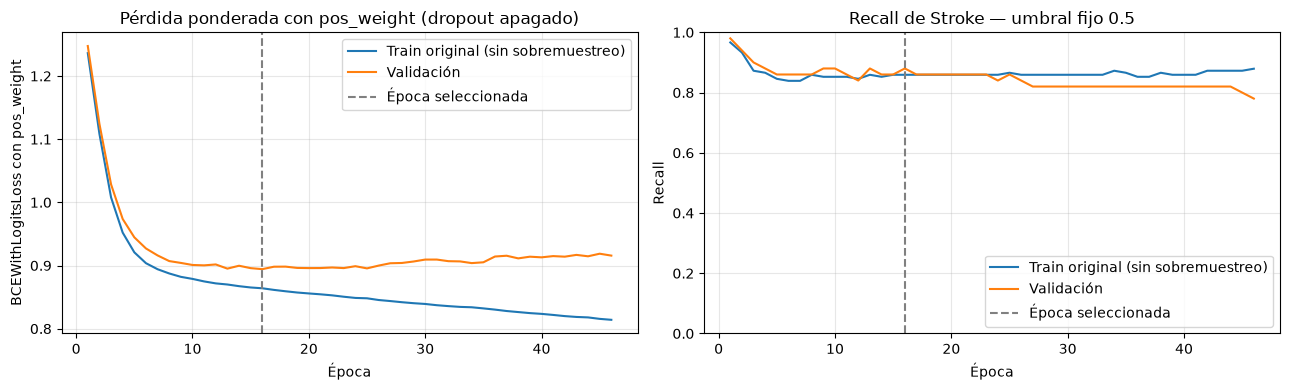

In [66]:
epochs_run = [row["epoch"] for row in history_pos_weight]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for prefix, label in [
    ("train", "Train original (sin sobremuestreo)"),
    ("val", "Validación"),
]:
    axes[0].plot(
        epochs_run, [row[f"{prefix}_loss"] for row in history_pos_weight], label=label
    )
    axes[1].plot(
        epochs_run, [row[f"{prefix}_recall"] for row in history_pos_weight], label=label
    )

axes[0].set_title("Pérdida ponderada con pos_weight (dropout apagado)")
axes[0].set_ylabel("BCEWithLogitsLoss con pos_weight")
axes[1].set_title("Recall de Stroke — umbral fijo 0.5")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1)
for ax in axes:
    ax.axvline(
        best_epoch_pos_weight, color="gray", linestyle="--", label="Época seleccionada"
    )
    ax.set_xlabel("Época")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


Con `pos_weight`, se selecciona la época 16 por pérdida de validación 0.8943 y se detiene en la 46 tras 30 épocas sin mejora suficiente. La pérdida de train continúa bajando (0.8788 en la época 10 y 0.8235 en la 40), mientras validación deja de mejorar y llega a 0.9130 en la 40. Ese comportamiento sugiere sobreajuste y respalda restaurar un checkpoint anterior.

El recall de validación a umbral 0.5 oscila aproximadamente entre 0.79 y 0.88 en las épocas mostradas

La pérdida ponderada no se compara numéricamente con la BCE sin ponderar de BorderlineSMOTE porque cambió la función objetivo. Por eso la comparación que vale entre modelos es la que realizaremos con F2, precisión, recall, AUC y AP sobre las mismas filas de validación


## 7. Comparación de arquitecturas MLP

Se toma el MLP original de una capa oculta de 64 neuronas como referencia y se compara con dos alternativas: una capa de 32 neuronas y dos capas de 64 y 32 neuronas. La primera permite examinar si reducir la capacidad conserva el desempeño y la segunda permite evaluar el efecto de agregar profundidad. En los tres casos se construye un MLP para clasificación binaria.

Se mantienen la partición, el preprocesamiento, `pos_weight`, Adam (lr=0.001, weight_decay=0.0001), batch size 64 y ReLU con dropout 0.3 después de cada capa oculta. Se utiliza la misma semilla `SEED = 42` para las tres arquitecturas, hasta 500 épocas y paciencia 30. Se seleccionan los pesos por pérdida de validación y el umbral por F2. Al agregar una capa también se incorpora un bloque adicional de ReLU y dropout y se comparan las configuraciones completas bajo esa regla común.

La comparación utiliza únicamente train y validación


### 7.1. Funciones de evaluación y selección de umbral


In [67]:
from sklearn.metrics import fbeta_score, average_precision_score


def probabilidades_validacion(modelo, features):
    parameter = next(modelo.parameters())
    features_tensor = torch.tensor(
        np.asarray(features), dtype=torch.float32, device=parameter.device
    )
    modelo.eval()
    with torch.no_grad():
        probabilities = torch.sigmoid(modelo(features_tensor)).cpu().numpy().reshape(-1)
    if not np.isfinite(probabilities).all():
        raise ValueError("Se obtuvieron probabilidades no finitas.")
    return probabilities


def metricas_binarias(labels, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        "Umbral": float(threshold),
        "Accuracy": accuracy_score(labels, predictions),
        "Precision": precision_score(labels, predictions, zero_division=0),
        "Recall": recall_score(labels, predictions, zero_division=0),
        "F1": f1_score(labels, predictions, zero_division=0),
        "F2": fbeta_score(labels, predictions, beta=2, zero_division=0),
        "AUC_ROC": roc_auc_score(labels, probabilities),
        "AP": average_precision_score(labels, probabilities),
        "Especificidad": tn / (tn + fp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Alertas": int(tp + fp),
    }


def elegir_umbral_f2(labels, probabilities):
    # Una fila por umbral observado: cubre todos los cambios de clasificación.
    precision, recall, thresholds = precision_recall_curve(labels, probabilities)
    # El último punto de la curva no tiene un umbral asociado.
    precision, recall = precision[:-1], recall[:-1]
    denominator = 4 * precision + recall
    scores = np.divide(
        5 * precision * recall,
        denominator,
        out=np.zeros_like(denominator),
        where=denominator > 0,
    )
    candidates = pd.DataFrame(
        {
            "Umbral": thresholds,
            "Precision": precision,
            "Recall": recall,
            "F2": scores,
        }
    )
    denominator_f1 = precision + recall
    candidates["F1"] = np.divide(
        2 * precision * recall,
        denominator_f1,
        out=np.zeros_like(denominator_f1),
        where=denominator_f1 > 0,
    )
    # Empates numéricos en F2: preferir mayor precisión y luego mayor umbral.
    tied = candidates[
        np.isclose(candidates["F2"], candidates["F2"].max(), rtol=0, atol=1e-12)
    ]
    best = tied.sort_values(["Precision", "Umbral"], ascending=[False, False]).iloc[0]
    return float(best["Umbral"]), candidates


def elegir_umbral_f1(labels, probabilities):
    # Se conservan los mismos candidatos y la misma regla de desempate.
    _, candidates = elegir_umbral_f2(labels, probabilities)
    tied = candidates[
        np.isclose(candidates["F1"], candidates["F1"].max(), rtol=0, atol=1e-12)
    ]
    best = tied.sort_values(["Precision", "Umbral"], ascending=[False, False]).iloc[0]
    return float(best["Umbral"]), candidates




En el bloque anterior se definen funciones comunes para comparar métricas y elegir umbrales exclusivamente en validación. Se reutilizan posteriormente en la comparación de los métodos de tratamiento del desbalance.

El umbral convierte scores en etiquetas y las funciones calculan métricas sobre scores y decisiones y seleccionan candidatos observados por F1 o F2 con una regla reproducible de desempate.


### 7.2. Entrenamiento y comparación de tres arquitecturas

Se entrena una vez cada MLP con la misma semilla definida al inicio. Se presentan métricas individuales de validación, sin promedios ni desvíos entre semillas.


In [68]:
import time


def comparar_arquitecturas():
    # Las variables y los modelos experimentales quedan dentro de esta función.

    MAX_EPOCHS, PATIENCE, MIN_DELTA = 500, 30, 1e-4
    BATCH_SIZE, LEARNING_RATE, WEIGHT_DECAY, DROPOUT = 64, 0.001, 1e-4, 0.3
    input_dim = X_train_prep.shape[1]
    Xtr = torch.tensor(np.asarray(X_train_prep), dtype=torch.float32)
    ytr = torch.tensor(np.asarray(y_train), dtype=torch.float32).reshape(-1, 1)
    Xva = torch.tensor(np.asarray(X_val_prep), dtype=torch.float32)
    yva = torch.tensor(np.asarray(y_val), dtype=torch.float32).reshape(-1, 1)
    labels_val = np.asarray(y_val)
    pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()], dtype=torch.float32)
    class Arquitectura(nn.Module):
        def __init__(self, input_dim, hidden_sizes):
            super().__init__()
            layers, previous = [], input_dim
            for width in hidden_sizes:
                layers.extend([nn.Linear(previous, width), nn.ReLU(), nn.Dropout(DROPOUT)])
                previous = width
            layers.append(nn.Linear(previous, 1))
            self.network = nn.Sequential(*layers)
        def forward(self, x):
            return self.network(x)


    def evaluar(model, loader, criterion):
        model.eval()
        loss_sum, total, tp, positives = 0.0, 0, 0, 0
        with torch.no_grad():
            for features, labels in loader:
                logits = model(features)
                loss_sum += criterion(logits, labels).item() * len(features)
                total += len(features)
                positive_mask = labels == 1
                positives += positive_mask.sum().item()
                tp += ((logits >= 0) & positive_mask).sum().item()
        return loss_sum / total, tp / positives


    def entrenar(name, hidden_sizes, seed):
        fijar_semilla(seed)
        train_dataset = TensorDataset(Xtr, ytr)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        model = Arquitectura(input_dim, hidden_sizes)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        train_eval = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
        val_eval = DataLoader(TensorDataset(Xva, yva), batch_size=BATCH_SIZE, shuffle=False)
        best_loss, best_epoch, best_weights, bad_epochs = float("inf"), None, None, 0
        history = []
        started = time.perf_counter()
        for epoch in range(1, MAX_EPOCHS + 1):
            model.train()
            for features, labels in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(features), labels)
                loss.backward(); optimizer.step()
            train_loss, train_recall = evaluar(model, train_eval, criterion)
            val_loss, val_recall = evaluar(model, val_eval, criterion)
            if not np.isfinite(train_loss) or not np.isfinite(val_loss):
                raise RuntimeError(f"Pérdida no finita: {name}, semilla {seed}.")
            history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
                            "train_recall": train_recall, "val_recall": val_recall})
            if val_loss < best_loss - MIN_DELTA:
                best_loss, best_epoch = val_loss, epoch
                best_weights = copy.deepcopy(model.state_dict()); bad_epochs = 0
            else:
                bad_epochs += 1
            if bad_epochs >= PATIENCE:break
        model.load_state_dict(best_weights); model.eval()
        restored_loss, _ = evaluar(model, val_eval, criterion)
        assert abs(restored_loss - best_loss) < 1e-8
        with torch.no_grad():scores = torch.sigmoid(model(Xva)).numpy().reshape(-1)
        threshold_f2, _ = elegir_umbral_f2(labels_val, scores)
        threshold_f1, _ = elegir_umbral_f1(labels_val, scores)
        row = {"Arquitectura": name, "Semilla": seed,
               "Capas": " → ".join(map(str, [input_dim, *hidden_sizes, 1])),
               "Parametros": sum(p.numel() for p in model.parameters()),
               "Mejor_epoca": best_epoch, "Epocas": len(history), "Val_loss": best_loss,
               "Segundos": time.perf_counter() - started,
               **metricas_binarias(labels_val, scores, threshold_f2)}
        baseline = metricas_binarias(labels_val, scores, 0.5)
        row.update({"F2_umbral_05": baseline["F2"], "Recall_umbral_05": baseline["Recall"],
                    "Umbral_F1": threshold_f1,
                    "F1_optimizado": metricas_binarias(labels_val, scores, threshold_f1)["F1"]})
        return row, history

    rows, histories = [], {}
    for name, hidden_sizes in {"MLP 64": (64,), "MLP 32": (32,), "MLP 64-32": (64, 32)}.items():
        for seed in [SEED]:
            row, history = entrenar(name, hidden_sizes, seed)
            rows.append(row)
            histories[(name, seed)] = pd.DataFrame(history)
            print(f"{name} | semilla {seed}: F2={row['F2']:.4f}, "
                  f"precisión={row['Precision']:.3f}, recall={row['Recall']:.3f}, "
                  f"mejor época={row['Mejor_epoca']}", flush=True)
    return pd.DataFrame(rows), histories


# Se preservan los generadores y la configuración del entorno principal.
estado_random = random.getstate()
estado_numpy = np.random.get_state()
hilos_previos = torch.get_num_threads()
try:
    torch.set_num_threads(1)
    with torch.random.fork_rng(devices=[]):
        resultados_arquitecturas, historiales_arquitecturas = comparar_arquitecturas()
finally:
    random.setstate(estado_random)
    np.random.set_state(estado_numpy)
    torch.set_num_threads(hilos_previos)

resumen_arquitecturas = resultados_arquitecturas.set_index("Arquitectura")[
    ["Semilla", "Parametros", "F2", "Precision", "Recall", "FP", "FN", "Mejor_epoca"]
]
display(resumen_arquitecturas.round(4))


MLP 64 | semilla 42: F2=0.4366, precisión=0.149, recall=0.840, mejor época=16
MLP 32 | semilla 42: F2=0.4343, precisión=0.151, recall=0.820, mejor época=24
MLP 64-32 | semilla 42: F2=0.4310, precisión=0.152, recall=0.800, mejor época=9


,Semilla,Parametros,F2,Precision,Recall,FP,FN,Mejor_epoca
Arquitectura,,,,,,,,
MLP 64,42,1153,0.4366,0.1495,0.84,239,8,16
MLP 32,42,577,0.4343,0.1507,0.82,231,9,24
MLP 64-32,42,3201,0.4310,0.1515,0.80,224,10,9


Los resultados corresponden a una ejecución por arquitectura: F2 0.4366 (64), 0.4343 (32) y 0.4310 (64–32). Las diferencias son pequeñas, y la tabla también permite comparar errores y parámetros. La gráfica siguiente representa esos mismos F2, sin agregar experimentos ni incertidumbre.


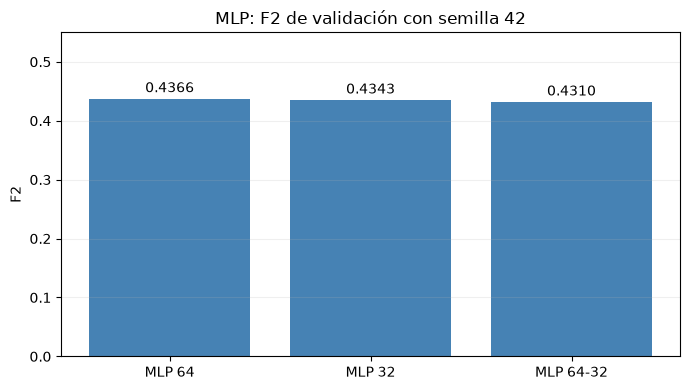

In [69]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(resumen_arquitecturas.index, resumen_arquitecturas["F2"], color="steelblue")
for posicion, valor in enumerate(resumen_arquitecturas["F2"]):
    ax.annotate(f"{valor:.4f}", xy=(posicion, valor), xytext=(0, 5),
                textcoords="offset points", ha="center")
ax.set_ylim(0, 0.55)
ax.set_title(f"MLP: F2 de validación con semilla {SEED}")
ax.set_ylabel("F2")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


### 7.3. Resultados y selección de arquitectura

Resultados prácticamente identicos. El MLP de 64 neuronas alcanza F2 de validación 0.4366, seguido por el de 32 (0.4343) y el de dos capas 64–32 (0.4310). Sus cantidades de parámetros son 1153, 577 y 3201, respectivamente. Reducir a 32 conserva un resultado muy cercano con aproximadamente la mitad de parámetros. Agregar profundidad aumenta la complejidad sin mejorar F2 en esta prueba.

Se mantiene el MLP de 64 por el criterio F2 definido: detecta 42 de los 50 positivos frente a 41 del MLP de 32, a cambio de ocho falsas alertas adicionales (239 frente a 231). La elección es coherente con dar mayor prioridad a recall, pero la diferencia de F2 es pequeña (0.0023). Aunque en este caso se selecciona la arquitectura de 64 neuronas por el contexto del problema priorizamos maximizar F2, el MLP de 32 sigue siendo una alternativa razonable si se priorizan simplicidad y menos falsos positivos.


## 8. Comparación de estrategias y selección en validación

### 8.1. Obtención de scores de validación

Se calculan scores de los dos modelos restaurados sobre exactamente los mismos pacientes de validación, sin gradientes. Se verifica que existan ambas clases y que las predicciones tengan la longitud esperada.


In [70]:
# Compatibilidad con un kernel donde el primer entrenamiento se ejecutó antes
# de agregar el nombre model_smote. El primer MLP sigue almacenado como model.
if "model_smote" not in globals():
    if "model" not in globals() or model.__class__.__name__ != "MLP":
        raise RuntimeError("Ejecutá primero el entrenamiento con SMOTE.")
    model_smote = copy.deepcopy(model)
if "model_pos_weight" not in globals():
    raise RuntimeError("Ejecutá primero el entrenamiento con pos_weight.")

labels_val = np.asarray(y_val).reshape(-1)
if set(np.unique(labels_val)) != {0, 1}:
    raise ValueError("Validación debe contener ambas clases.")
models_val = {
    "BorderlineSMOTE": model_smote,
    "pos_weight": model_pos_weight,
}
probabilities_val = {
    name: probabilidades_validacion(modelo, X_val_prep)
    for name, modelo in models_val.items()
}
if any(
    len(probabilities) != len(labels_val)
    for probabilities in probabilities_val.values()
):
    raise ValueError("Las predicciones deben estar alineadas con y_val.")

print(
    f"Validación: {len(labels_val)} pacientes; {int(labels_val.sum())} positivos "
    f"({labels_val.mean():.2%}). Ambos modelos usan las mismas filas."
)


Validación: 1022 pacientes; 50 positivos (4.89%). Ambos modelos usan las mismas filas.


### 8.2. Comparación con umbral fijo de 0,5

Ambos vectores de scores corresponden a los mismos 1022 pacientes y 50 positivos, de modo que las métricas pueden compararse sobre una base común. Se usa 0.5 como referencia inicial y se agrega un clasificador siempre negativo para mostrar el efecto del desbalance.


In [71]:
fixed_rows = [
    {
        "Modelo": name,
        "Regla": "Umbral 0.5",
        **metricas_binarias(labels_val, probabilities, 0.5),
    }
    for name, probabilities in probabilities_val.items()
]
fixed_rows.append(
    {
        "Modelo": "Referencia: siempre negativo",
        "Regla": "Umbral 0.5",
        **metricas_binarias(labels_val, np.zeros(len(labels_val)), 0.5),
    }
)
comparison_fixed = pd.DataFrame(fixed_rows)
display(comparison_fixed.round(4))


,Modelo,Regla,Umbral,Accuracy,Precision,Recall,F1,F2,AUC_ROC,AP,Especificidad,TN,FP,FN,TP,Alertas
0,BorderlineSMOTE,Umbral 0.5,0.5,0.8523,0.1469,0.42,0.2176,0.3061,0.8092,0.1459,0.8745,850,122,29,21,143
1,pos_weight,Umbral 0.5,0.5,0.7231,0.1371,0.88,0.2372,0.4223,0.8380,0.1631,0.7150,695,277,6,44,321
2,Referencia: siempre negativo,Umbral 0.5,0.5,0.9511,0.0000,0.00,0.0000,0.0000,0.5000,0.0489,1.0000,972,0,50,0,0


A umbral 0.5, la referencia siempre negativa obtiene la mayor accuracy (0.9511), pero omite los 50 positivos: recall, F1 y F2 son cero. Su precisión se informa como cero por la convención `zero_division=0`, ya que no genera alertas. Es a causa del desbalanceo que accuracy aislada es engañosa.

BorderlineSMOTE detecta 21 positivos y omite 29, con 122 falsas alertas. `pos_weight` detecta 44 y omite 6, pero genera 277 falsas alertas. Así, el segundo aumenta recall de 0.42 a 0.88 y F2 de 0.3061 a 0.4223, con menor especificidad y accuracy. Las precisiones siguen siendo bajas: 0.1469 y 0.1371. La ponderación favorece detecciones en esta configuración, sin resolver por sí sola el costo de falsas alertas.


### 8.3. Selección de umbrales mediante F1 y F2

Se evalúan los cambios de clasificación en los umbrales observados y se conservan los que maximizan F1 y F2 en validación. La configuración se ordena por F2; los desempates definidos en código evitan elecciones manuales posteriores.


In [72]:
thresholds_f2 = {}
thresholds_f1 = {}
optimized_rows_f1 = []
threshold_curves = {}
optimized_rows = []
for name, probabilities in probabilities_val.items():
    threshold, candidates = elegir_umbral_f2(labels_val, probabilities)
    threshold_f1, _ = elegir_umbral_f1(labels_val, probabilities)
    thresholds_f1[name] = threshold_f1
    optimized_rows_f1.append(
        {
            "Modelo": name,
            "Regla": "Umbral elegido por F1 en val",
            **metricas_binarias(labels_val, probabilities, threshold_f1),
        }
    )
    thresholds_f2[name] = threshold
    threshold_curves[name] = candidates
    optimized_rows.append(
        {
            "Modelo": name,
            "Regla": "Umbral elegido por F2 en val",
            **metricas_binarias(labels_val, probabilities, threshold),
        }
    )
comparison_f2 = pd.DataFrame(optimized_rows)
comparison_f1 = pd.DataFrame(optimized_rows_f1)
comparison_thresholds = pd.concat([comparison_f1, comparison_f2], ignore_index=True)
display(comparison_thresholds.round(4))

# Selección reproducible por F2; en empate se prefiere precisión y luego recall.
ranked = comparison_f2.sort_values(
    ["F2", "Precision", "Recall", "Modelo"], ascending=[False, False, False, True]
)
selected_name = ranked.iloc[0]["Modelo"]
selected_model = models_val[selected_name]
selected_threshold = thresholds_f2[selected_name]
print(f"Configuración seleccionada en validación: {selected_name}")
print(f"Umbral que se conservaría para test: {selected_threshold:.6f}")


,Modelo,Regla,Umbral,Accuracy,Precision,Recall,F1,F2,AUC_ROC,AP,Especificidad,TN,FP,FN,TP,Alertas
0,BorderlineSMOTE,Umbral elegido por F1 en val,0.5449,0.8689,0.1667,0.42,0.2386,0.3221,0.8092,0.1459,0.8920,867,105,29,21,126
1,pos_weight,Umbral elegido por F1 en val,0.7138,0.8415,0.1706,0.58,0.2636,0.3919,0.8380,0.1631,0.8549,831,141,21,29,170
2,BorderlineSMOTE,Umbral elegido por F2 en val,0.0838,0.7182,0.1234,0.78,0.2131,0.3779,0.8092,0.1459,0.7150,695,277,11,39,316
3,pos_weight,Umbral elegido por F2 en val,0.5674,0.7583,0.1495,0.84,0.2538,0.4366,0.8380,0.1631,0.7541,733,239,8,42,281


Configuración seleccionada en validación: pos_weight
Umbral que se conservaría para test: 0.567368


**Justificación de F2 y lectura de los umbrales**

Se usa $F_2=5PR/(4P+R)=5TP/(5TP+4FN+FP)$, donde $P$ es precisión y $R$, recall. 

En comparación con F1, F2 da mayor importancia a recall: en su expresión por conteos, los FN tienen coeficiente cuatro frente a uno para FP. Esto se decidió porque se prefiere tener menos falsos negativos. F2 tampoco impone un mínimo aceptable de precisión.

Con `pos_weight`, maximizar F1 selecciona umbral 0.7138, precisión 0.1706 y recall 0.58; maximizar F2 selecciona 0.567368, precisión 0.1495 y recall 0.84. Se aceptan más falsas alertas para detectar más positivos que con el umbral F1. Sin embargo, el umbral F2 es mayor que 0.5: F2 equilibra ambas métricas y no equivale a maximizar recall sin restricciones.

En BorderlineSMOTE, el umbral F2 baja a 0.0838 y eleva recall a 0.78, con precisión 0.1234. Los umbrales no son comparables como niveles de riesgo clínico: los métodos modifican la escala de los scores y no se evaluó calibración.

### 8.4. Matrices de confusión

Se muestran los conteos para cada modelo con 0.5 y con su umbral F2. Esto permite ver cuántas detecciones y falsas alertas se intercambian al modificar la decisión.


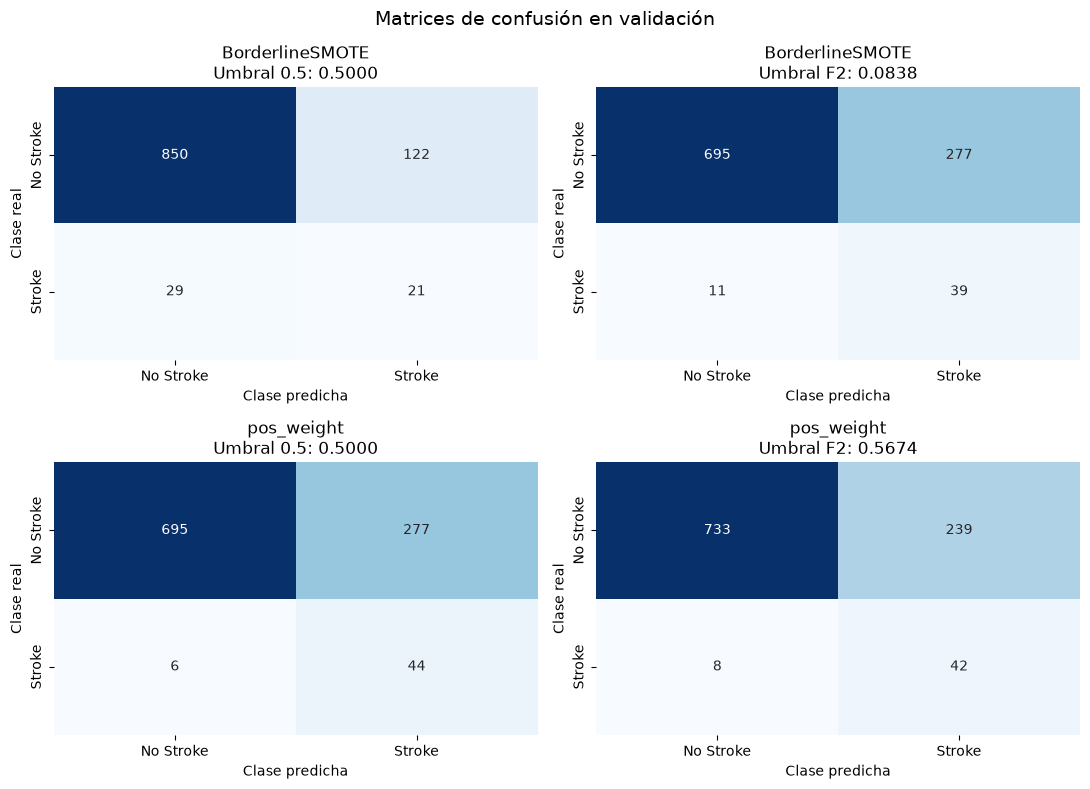

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for row, (name, probabilities) in enumerate(probabilities_val.items()):
    for col, (rule, threshold) in enumerate(
        [
            ("Umbral 0.5", 0.5),
            ("Umbral F2", thresholds_f2[name]),
        ]
    ):
        predictions = (probabilities >= threshold).astype(int)
        matrix = confusion_matrix(labels_val, predictions, labels=[0, 1])
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=["No Stroke", "Stroke"],
            yticklabels=["No Stroke", "Stroke"],
            ax=axes[row, col],
        )
        axes[row, col].set_title(f"{name}\n{rule}: {threshold:.4f}")
        axes[row, col].set_xlabel("Clase predicha")
        axes[row, col].set_ylabel("Clase real")
fig.suptitle("Matrices de confusión en validación", fontsize=14)
plt.tight_layout()
plt.show()


Observamos que en BorderlineSMOTE bajar el umbral de 0.5 al seleccionado por F2 cambia TP de 21 a 39 y FN de 29 a 11: recupera 18 positivos. A cambio, FP aumenta de 122 a 277 y TN baja de 850 a 695. Se generan 155 falsos positivos adicionales.

En `pos_weight`, subir de 0.5 a 0.567368 cambia TP de 44 a 42 y FN de 6 a 8, pero reduce FP de 277 a 239 y aumenta TN de 695 a 733. Se pierden dos detecciones a cambio de 38 falsas alertas menos, y F2 mejora de 0.4223 a 0.4366.

Estos conteos muestran el compromiso que la métrica resume. Se muestra que curiosamente priorizar recall no exige elegir siempre el umbral más bajo, y esto es porque la precisión también interviene en F2. El criterio elegido acepta ese compromiso.

### 8.5. Curvas ROC, precisión-recall y métricas según el umbral



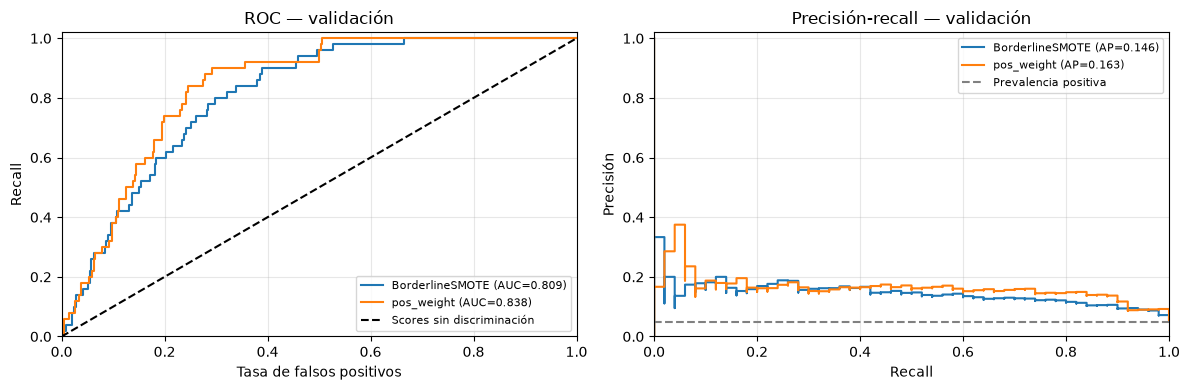

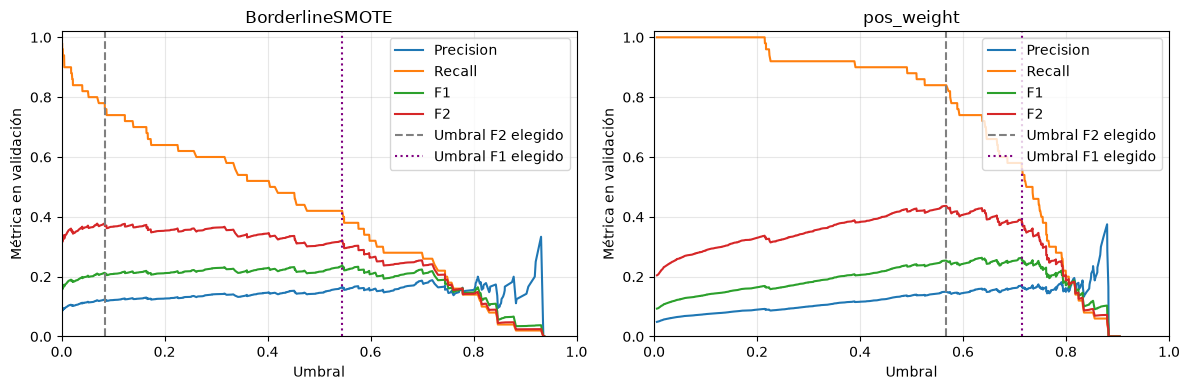

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, probabilities in probabilities_val.items():
    fpr, tpr, _ = roc_curve(labels_val, probabilities)
    precision, recall, _ = precision_recall_curve(labels_val, probabilities)
    axes[0].plot(
        fpr, tpr, label=f"{name} (AUC={roc_auc_score(labels_val, probabilities):.3f})"
    )
    axes[1].step(
        recall,
        precision,
        where="post",
        label=f"{name} (AP={average_precision_score(labels_val, probabilities):.3f})",
    )
axes[0].plot([0, 1], [0, 1], "k--", label="Scores sin discriminación")
axes[0].set(
    title="ROC — validación", xlabel="Tasa de falsos positivos", ylabel="Recall"
)
axes[1].axhline(
    labels_val.mean(), color="gray", linestyle="--", label="Prevalencia positiva"
)
axes[1].set(title="Precisión-recall — validación", xlabel="Recall", ylabel="Precisión")
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, candidates) in zip(axes, threshold_curves.items()):
    for metric in ["Precision", "Recall", "F1", "F2"]:
        ax.plot(candidates["Umbral"], candidates[metric], label=metric)
    ax.axvline(
        thresholds_f2[name], color="gray", linestyle="--", label="Umbral F2 elegido"
    )
    ax.axvline(
        thresholds_f1[name], color="purple", linestyle=":", label="Umbral F1 elegido"
    )
    ax.set(
        title=name,
        xlabel="Umbral",
        ylabel="Métrica en validación",
        xlim=(0, 1),
        ylim=(0, 1.02),
    )
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


En validación, `pos_weight` obtiene mejores resultados que BorderlineSMOTE:

| Métrica | `pos_weight` | BorderlineSMOTE |
| --- | --- | --- |
| AUC-ROC | 0.8380 | 0.8092 |
| AP | 0.1631 | 0.1459 |

**AUC-ROC** mide qué tan bien el modelo asigna scores mayores a los positivos que a los negativos.

**AP (Average Precision)** resume la precisión al variar el umbral y detectar más positivos. Un valor mayor es mejor. La referencia sin información es la proporción de positivos: 0.0489 (4.89 %). Ambos modelos la superan aunqueno dejan de tener muchos falsos positivos.

Al cambiar el umbral cambian precisión, recall, F1 y F2, en cambio AUC-ROC y AP permanecen iguales porque usan los scores. Estos resultados favorecen a `pos_weight`.

### 8.6. Comparación final y selección de configuración

Ambos modelos usan la misma arquitectura e hiperparámetros. BorderlineSMOTE agrega ejemplos sintéticos y `pos_weight` da más peso a los positivos en la pérdida. Para cada modelo se eligen los pesos y el umbral usando validación.

| Resultado en validación | `pos_weight` | BorderlineSMOTE |
| --- | --- | --- |
| F2 | 0.4366 | 0.3779 |
| Recall | 0.84 | 0.78 |
| Falsos positivos (FP) | 239 | 277 |
| Falsos negativos (FN) | 8 | 11 |
| True positives (TP) | 42 | 39 |
| True negativos (TN) | 733 | 695 |

Se elige **`pos_weight`** porque obtiene mayor F2, detecta más positivos y genera menos falsas alertas (en esta validación).

In [75]:
winner = ranked.iloc[0]
print(f"Selección provisional por F2 en val: {selected_name}.")
for _, row in comparison_f2.iterrows():
    original = comparison_fixed[comparison_fixed["Modelo"] == row["Modelo"]].iloc[0]
    print(
        f"\n{row['Modelo']}: umbral={row['Umbral']:.4f}; F2 {original['F2']:.3f} -> {row['F2']:.3f}."
    )
    print(
        f"Precisión={row['Precision']:.3f}, recall={row['Recall']:.3f}, F1={row['F1']:.3f}; "
        f"True positives (TP)={int(row['TP'])}, falsos negativos (FN)={int(row['FN'])}, "
        f"falsos positivos (FP)={int(row['FP'])}, true negativos (TN)={int(row['TN'])}."
    )
    print(
        f"Predicciones positivas: {int(row['Alertas'])}; falsos positivos (FP): {int(row['FP'])}. "
        f"Frente a 0.5: cambio en falsos negativos (FN)={int(row['FN'] - original['FN']):+d}, "
        f"cambio en falsos positivos (FP)={int(row['FP'] - original['FP']):+d}."
    )


Selección provisional por F2 en val: pos_weight.

BorderlineSMOTE: umbral=0.0838; F2 0.306 -> 0.378.
Precisión=0.123, recall=0.780, F1=0.213; True positives (TP)=39, falsos negativos (FN)=11, falsos positivos (FP)=277, true negativos (TN)=695.
Predicciones positivas: 316; falsos positivos (FP): 277. Frente a 0.5: cambio en falsos negativos (FN)=-18, cambio en falsos positivos (FP)=+155.

pos_weight: umbral=0.5674; F2 0.422 -> 0.437.
Precisión=0.149, recall=0.840, F1=0.254; True positives (TP)=42, falsos negativos (FN)=8, falsos positivos (FP)=239, true negativos (TN)=733.
Predicciones positivas: 281; falsos positivos (FP): 239. Frente a 0.5: cambio en falsos negativos (FN)=+2, cambio en falsos positivos (FP)=-38.


**Interpretación de la selección**

La configuración fijada es `pos_weight`, con arquitectura 16–64–1, checkpoint de época 16 y umbral 0.567368. En validación genera 281 alertas, de las cuales 42 son positivas y 239 falsas. Su mayor F2 no implica alta precisión: aproximadamente el 85 % de sus alertas son falsas en este conjunto.

## 9. Evaluación final en test

### 9.1. Métricas de la configuración seleccionada


In [76]:
# Se conservan la configuración y el umbral seleccionados en validación.
if not all(nombre in globals() for nombre in [
    "selected_name", "selected_model", "selected_threshold", "metricas_binarias"
]):
    raise RuntimeError("Se debe ejecutar primero la selección en validación.")

nombre_test = selected_name
umbral_test = float(selected_threshold)
modelo_test = selected_model
if not np.isfinite(umbral_test) or not 0 <= umbral_test <= 1:
    raise ValueError("El umbral seleccionado debe ser finito y estar entre 0 y 1.")

labels_test = np.asarray(y_test).reshape(-1)
if set(np.unique(labels_test)) != {0, 1}:
    raise ValueError("Test debe contener ambas clases para calcular AUC-ROC.")

parameter = next(modelo_test.parameters())
features_test = torch.tensor(
    np.asarray(X_test_prep), dtype=torch.float32, device=parameter.device
)
modelo_test.eval()
with torch.no_grad():
    probabilities_test = torch.sigmoid(modelo_test(features_test)).cpu().numpy().reshape(-1)

if len(probabilities_test) != len(labels_test) or not np.isfinite(probabilities_test).all():
    raise ValueError("Se requieren scores finitos y alineados con y_test.")

predictions_test = (probabilities_test >= umbral_test).astype(int)
resultados_test = metricas_binarias(labels_test, probabilities_test, umbral_test)
comparison_test = pd.DataFrame([
    {"Modelo": nombre_test, "Conjunto": "Test", **resultados_test}
])
print(f"Configuración fijada en validación: {nombre_test}; umbral F2 = {umbral_test:.6f}")
print(f"Test: {len(labels_test)} pacientes; {int(labels_test.sum())} positivos ({labels_test.mean():.2%}).")
display(comparison_test.round(4))


Configuración fijada en validación: pos_weight; umbral F2 = 0.567368
Test: 1022 pacientes; 50 positivos (4.89%).


,Modelo,Conjunto,Umbral,Accuracy,Precision,Recall,F1,F2,AUC_ROC,AP,Especificidad,TN,FP,FN,TP,Alertas
0,pos_weight,Test,0.5674,0.7564,0.1434,0.8,0.2432,0.4175,0.8487,0.3151,0.7541,733,239,10,40,279


**Lectura de las métricas de test**

| Métrica | Resultado | Interpretación |
| --- | --- | --- |
| Accuracy | 75.64 % | total de predicciones correctas |
| Precisión | 14.34 % | De cada 100 predicciones positivas 14 son correctas |
| Recall | 80 % | Se detectan 40 de los 50 positivos |
| Especificidad | 75.41 % | Se clasifican correctamente 733 de los 972 negativos |
| F1 | 0.2432 | precisión y recall con igual importancia |
| F2 | 0.4175 | más importancia a recall |

El modelo detecta la mayoría de los positivos pero muchas predicciones positivas son falsas. F2 supera a F1 porque da más importancia al recall, que es alto frente a la precisión

### 9.2. Matriz de confusión y curvas ROC y precisión-recall

La **matriz de confusión** muestra los aciertos y errores con el umbral elegido en validación. Las **curvas ROC y precisión-recall** muestran el comportamiento de los scores al variar el umbral, sin elegir uno nuevo con test. En precisión-recall, la línea de referencia indica la proporción de positivos del conjunto (4.89 %).


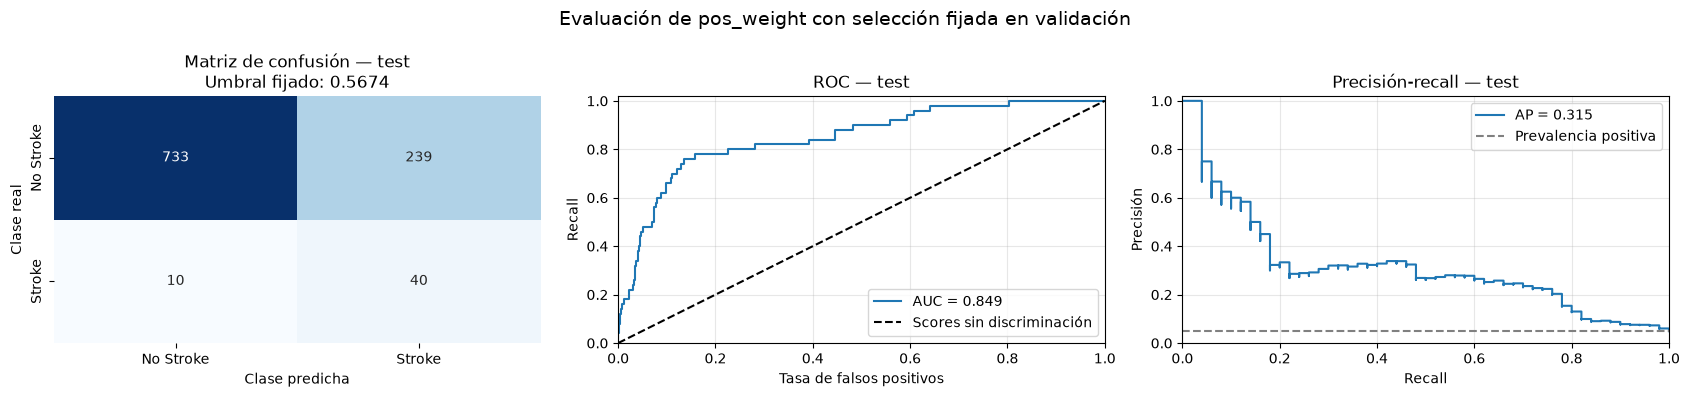

In [77]:
matrix_test = confusion_matrix(labels_test, predictions_test, labels=[0, 1])
fpr_test, tpr_test, _ = roc_curve(labels_test, probabilities_test)
precision_test, recall_test, _ = precision_recall_curve(labels_test, probabilities_test)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.heatmap(
    matrix_test, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["No Stroke", "Stroke"], yticklabels=["No Stroke", "Stroke"],
    ax=axes[0],
)
axes[0].set_title(f"Matriz de confusión — test\nUmbral fijado: {umbral_test:.4f}")
axes[0].set_xlabel("Clase predicha")
axes[0].set_ylabel("Clase real")

axes[1].plot(fpr_test, tpr_test, label=f"AUC = {resultados_test['AUC_ROC']:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", label="Scores sin discriminación")
axes[1].set(title="ROC — test", xlabel="Tasa de falsos positivos", ylabel="Recall")

axes[2].step(recall_test, precision_test, where="post", label=f"AP = {resultados_test['AP']:.3f}")
axes[2].axhline(labels_test.mean(), color="gray", linestyle="--", label="Prevalencia positiva")
axes[2].set(title="Precisión-recall — test", xlabel="Recall", ylabel="Precisión")
for ax in axes[1:]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle(f"Evaluación de {nombre_test} con selección fijada en validación", fontsize=14)
plt.tight_layout()
plt.show()


**Matriz y las curvas de test** - Interpretación

| Resultado | Pacientes | Significado |
| --- | --- | --- |
| True positives (TP) | 40 | Positivos detectados correctamente. |
| Falsos negativos (FN) | 10 | Positivos que el modelo clasificó como negativos. |
| Falsos positivos (FP) | 239 | Negativos que el modelo clasificó como positivos. |
| True negativos (TN) | 733 | Negativos clasificados correctamente. |

**Curva ROC:** está por encima de la diagonal y alcanza AUC-ROC de 0.8487. Esto indica que los scores permiten distinguir entre positivos y negativos mejor que un orden azaroso.

**Curva precisión-recall:** muestra que al intentar detectar más positivos, la precisión naja. La precisión promedio (AP) es 0.3151, por encima de la referencia de 0.0489 (4.89 % de positivos). La precisión con el umbral elegido es 0.1434.

Las curvas muestran capacidad para distinguir las clases, pero la matriz deja claro el compromiso final: **40 positivos detectados, 10 omitidos y 239 falsos positivos**.

### 9.3. Resumen de la evaluación final

A continuación se reúnen los conteos y las métricas principales para resumir el resultado del modelo.


In [78]:
print("RESULTADOS EN TEST")
print(f"True positives (TP): {resultados_test['TP']}")
print(f"Falsos negativos (FN): {resultados_test['FN']}")
print(f"Falsos positivos (FP): {resultados_test['FP']}")
print(f"True negativos (TN): {resultados_test['TN']}")

print("\nMÉTRICAS CON EL UMBRAL ELEGIDO")
print(f"Recall: {resultados_test['Recall']:.2%} — positivos detectados.")
print(f"Precisión: {resultados_test['Precision']:.2%} — predicciones positivas correctas.")
print(f"Accuracy: {resultados_test['Accuracy']:.2%} — predicciones correctas en total.")
print(f"F1: {resultados_test['F1']:.3f} | F2: {resultados_test['F2']:.3f}")

print("\nMÉTRICAS SOBRE LOS SCORES")
print(f"AUC-ROC: {resultados_test['AUC_ROC']:.3f}")
print(f"AP (precisión promedio): {resultados_test['AP']:.3f}")

print(f"\nReferencia siempre negativa: accuracy {1 - labels_test.mean():.2%}, "
      "sin detectar ningún positivo.")
print("Se mantienen el modelo y el umbral elegidos en validación.")


RESULTADOS EN TEST
True positives (TP): 40
Falsos negativos (FN): 10
Falsos positivos (FP): 239
True negativos (TN): 733

MÉTRICAS CON EL UMBRAL ELEGIDO
Recall: 80.00% — positivos detectados.
Precisión: 14.34% — predicciones positivas correctas.
Accuracy: 75.64% — predicciones correctas en total.
F1: 0.243 | F2: 0.418

MÉTRICAS SOBRE LOS SCORES
AUC-ROC: 0.849
AP (precisión promedio): 0.315

Referencia siempre negativa: accuracy 95.11%, sin detectar ningún positivo.
Se mantienen el modelo y el umbral elegidos en validación.


**Interpretación conjunta y efecto de los falsos negativos**

**Falsos negativos:** se omiten 10 de los 50 positivos (20 %). Si una predicción negativa se usara para descartar una revisión, esos casos quedarían sin señalar. Por eso se prioriza recall, aunque este modelo no está validado para tomar decisiones clínicas.

**Falsos positivos:** de las 279 predicciones positivas, 239 son incorrectas. La precisión es 14.34 %: hay aproximadamente seis falsos positivos por cada positivo detectado correctamente. Esto implicaría muchas revisiones innecesarias en una posible aplicación.

**Comparación con validación**

| Resultado | Validación | Test |
| --- | --- | --- |
| True positives (TP) | 42 | 40 |
| Falsos negativos (FN) | 8 | 10 |
| Falsos positivos (FP) | 239 | 239 |
| True negativos (TN) | 733 | 733 |
| Recall | 84 % | 80 % |
| F2 | 0.4366 | 0.4175 |
| AUC-ROC | 0.8380 | 0.8487 |
| AP (precisión promedio) | 0.1631 | 0.3151 |

En test se detectan dos positivos menos con el umbral elegido, aunque AUC-ROC y AP aumentan. No es una contradicción: las curvas evalúan la ordenación de los scores y recall evalúa una decisión con un umbral concreto. Con solo 50 positivos por conjunto, estas diferencias no demuestran una mejora generalizable.

Predecir siempre negativo lograría **95.11 % de accuracy**, pero omitiría todos los positivos. El MLP detecta 40, a cambio de 239 falsos positivos: ese compromiso explica por qué accuracy sola no alcanza para evaluarlo.


## 10. Conclusiones, limitaciones, posibles mejoras y resumen general

Se separaron los datos en entrenamiento, validación y test, conservando la proporción de positivos. Se eliminó `id`, se completaron los BMI faltantes con medianas calculadas en train, se codificaron las categorías con One-Hot y se escalaron las variables continuas.

Con validación se eligió el MLP de 16 entradas, 64 neuronas ocultas y una salida, con `pos_weight=19.58`. Se conservaron los pesos de la época 16 y el umbral 0.567368, elegido por F2. Las otras arquitecturas obtuvieron resultados cercanos.

En test se detectaron **40 de los 50 positivos (recall del 80 %)** y se omitieron 10. También hubo **239 falsos positivos**, por lo que solo el 14.34 % de las predicciones positivas fueron correctas. El modelo alcanzó F2 de 0.4175 y AUC-ROC de 0.8487.

El resultado refleja el compromiso elegido en base al contexto del problema, que es detectar una gran parte de los positivos a cambio de muchas falsas alertas (falsos positivos).

**Limitaciones**

- **Pocos positivos para evaluar.** Validación y test tienen 50 positivos cada uno. Acertar o perder un caso cambia recall en dos puntos porcentuales. Falta estimar cuánto podrían variar las métricas.
- **Una sola partición y semilla.** Los resultados podrían cambiar al dividir los datos o inicializar la red de otra manera. Las pequeñas diferencias entre arquitecturas requieren más pruebas para saber si se mantienen.
- **Varias decisiones sobre la misma validación.** Se usó para elegir los pesos, la arquitectura, el método de balanceo y el umbral. Esa selección puede favorecer resultados especialmente buenos en ese conjunto.
- **Imputación de BMI.** Completar con medianas concentra valores en el centro de cada grupo. Se podría agregar comparaciones con otras estrategias de imputación.

**Posibles mejoras**

1. Repetir los experimentos con distintas particiones como por ejemplo k-fold cross validation, ajustando el preprocesamiento solo con el train de cada prueba.
2. Comparar formas de completar BMI, como la mediana global o las medianas por grupo. También agregar una variable que indique si el BMI estaba ausente. Posteriomente elegir la estrategia con validación.
3. Comparar el MLP con una regresión logística ponderada como alternativa más simple. Para el sobremuestreo, probar SMOTENC, que permite trabajar con variables numéricas y categóricas.
4. Definir cuántos positivos se busca detectar y cuántas falsas alertas se pueden aceptar. Elegir el umbral con validación según esos objetivos y mantenerlo al evaluar test.
5. Optimización de hiperparámetros con alguna herramienta como Optuna, Grid Search.

El trabajo muestra que tratar el desbalance y elegir el umbral ayuda a priorizar detecciones. Para valorar el resultado también hay que considerar cuántos positivos se omiten, cuántos falsos positivos se generan y qué tan confiable es la evaluación.
